In [7]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from numpy.random import default_rng
# from theano import tensor as tt
import pytensor.tensor as tt
from scipy import stats

In [2]:
%config InlineBackend.figure_format = 'retina'
warnings.simplefilter(action="ignore", category=(FutureWarning, UserWarning))
RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)
rng = default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89

#### Code 16.1

In [3]:
d = pd.read_csv("Data/Howell1.csv", sep=";", header=0)
d.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


In [4]:
# scale observed variables
d["w"] = d["weight"] / d["weight"].mean()
d["h"] = d["height"] / d["height"].mean()

#### Code 16.2

In [5]:
with pm.Model() as m16_1:
    sigma = pm.Exponential("sigma", 1)
    k = pm.Exponential("k", 0.5)
    p = pm.Beta("p", alpha=2, beta=18)
    mu = pm.Deterministic("mu", pm.math.log(np.pi * k * tt.pow(p, 2) * tt.pow(d.h, 3)))
    w = pm.Lognormal("w", mu, sigma, observed=d.w)

A prior predictive check is not done in the book, but it is alluded to: the author acknowledges that the priors could be improved, but the data will drive the posterior. So let's have a look at how bad these priors are.

Sampling: [k, p, sigma, w]
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:813: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


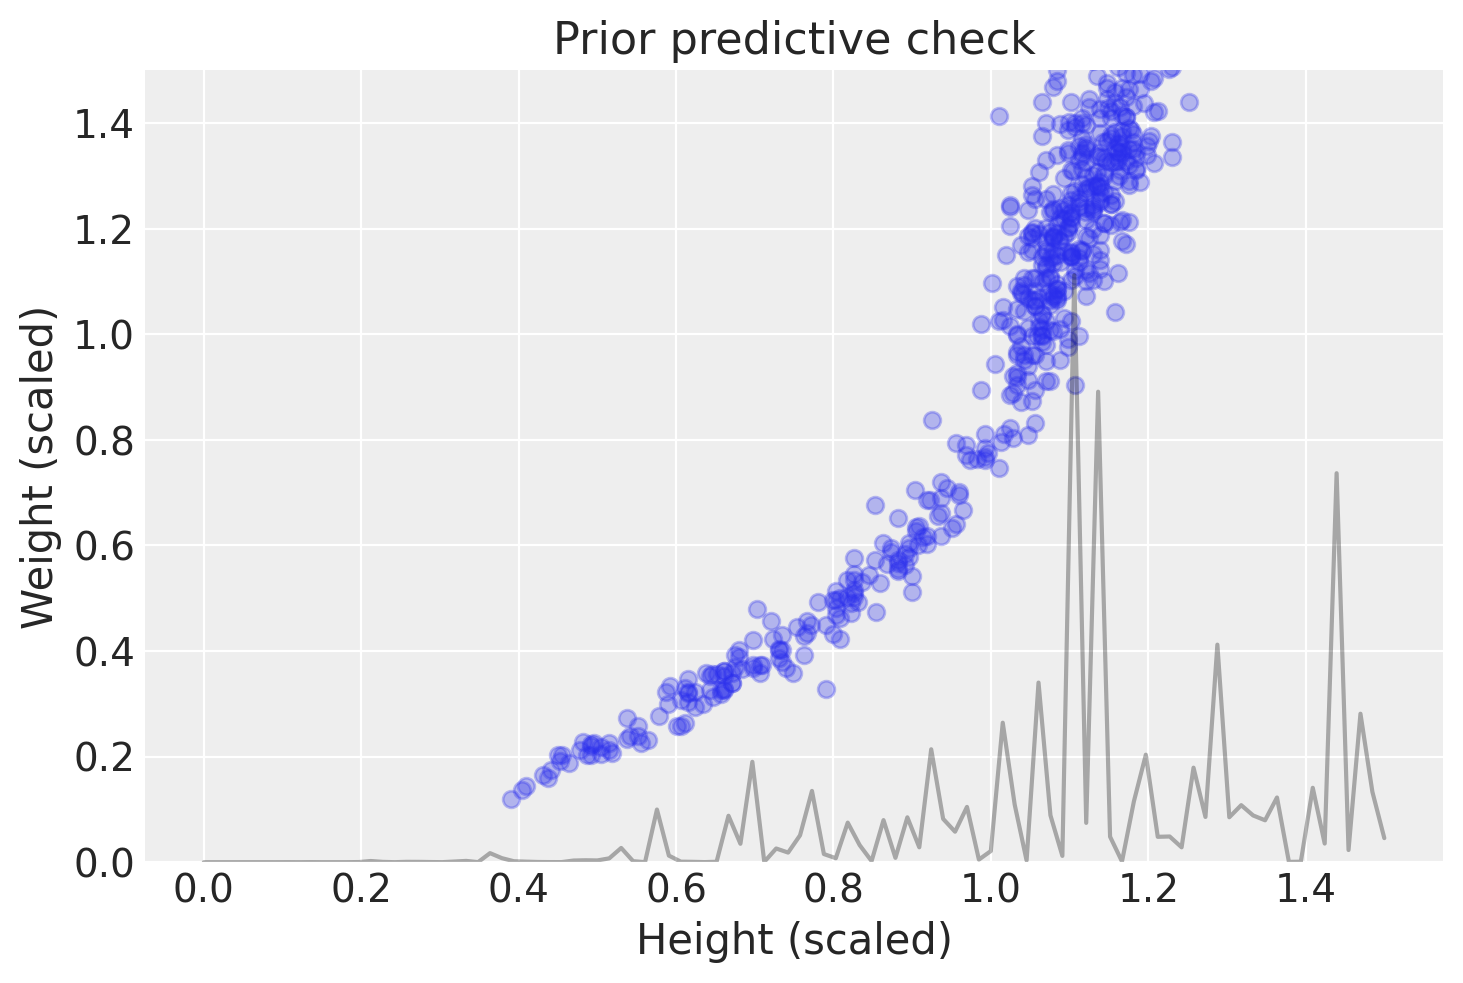

In [6]:
with m16_1:
    prior_checks = pm.sample_prior_predictive(samples=100)

_, ax = plt.subplots()
h_ppc = np.linspace(0, 1.5, 100)

for k, p in zip(prior_checks.prior["k"], prior_checks.prior["p"]):
    mu_ppc = np.log(np.pi * k * p**2 * h_ppc**3)
    w_ppc = np.exp(mu_ppc)  # Median of LogNormal
    ax.plot(h_ppc, w_ppc, c="k", alpha=0.3)

ax.scatter(d.h, d.w, c="C0", alpha=0.3)
ax.set_ylim([0, 1.5])
ax.set_xlabel("Height (scaled)")
ax.set_ylabel("Weight (scaled)")
ax.set_title("Prior predictive check");

So clearly some refinement in the priors could be made (e.g. try $k \sim \rm{Exp}(0.25)$ and $p \sim \rm{Beta}(2, 5)$), but let's stick with the priors in the book.

In [7]:
with m16_1:
    trace_16_1 = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, k, p]
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [8]:
varnames = ["~mu"]
az.summary(trace_16_1, kind="stats", var_names=varnames)

,mean,sd,hdi_5.5%,hdi_94.5%
sigma,0.207,0.006,0.196,0.217
k,5.639,2.690,1.826,9.106
p,0.250,0.058,0.161,0.338


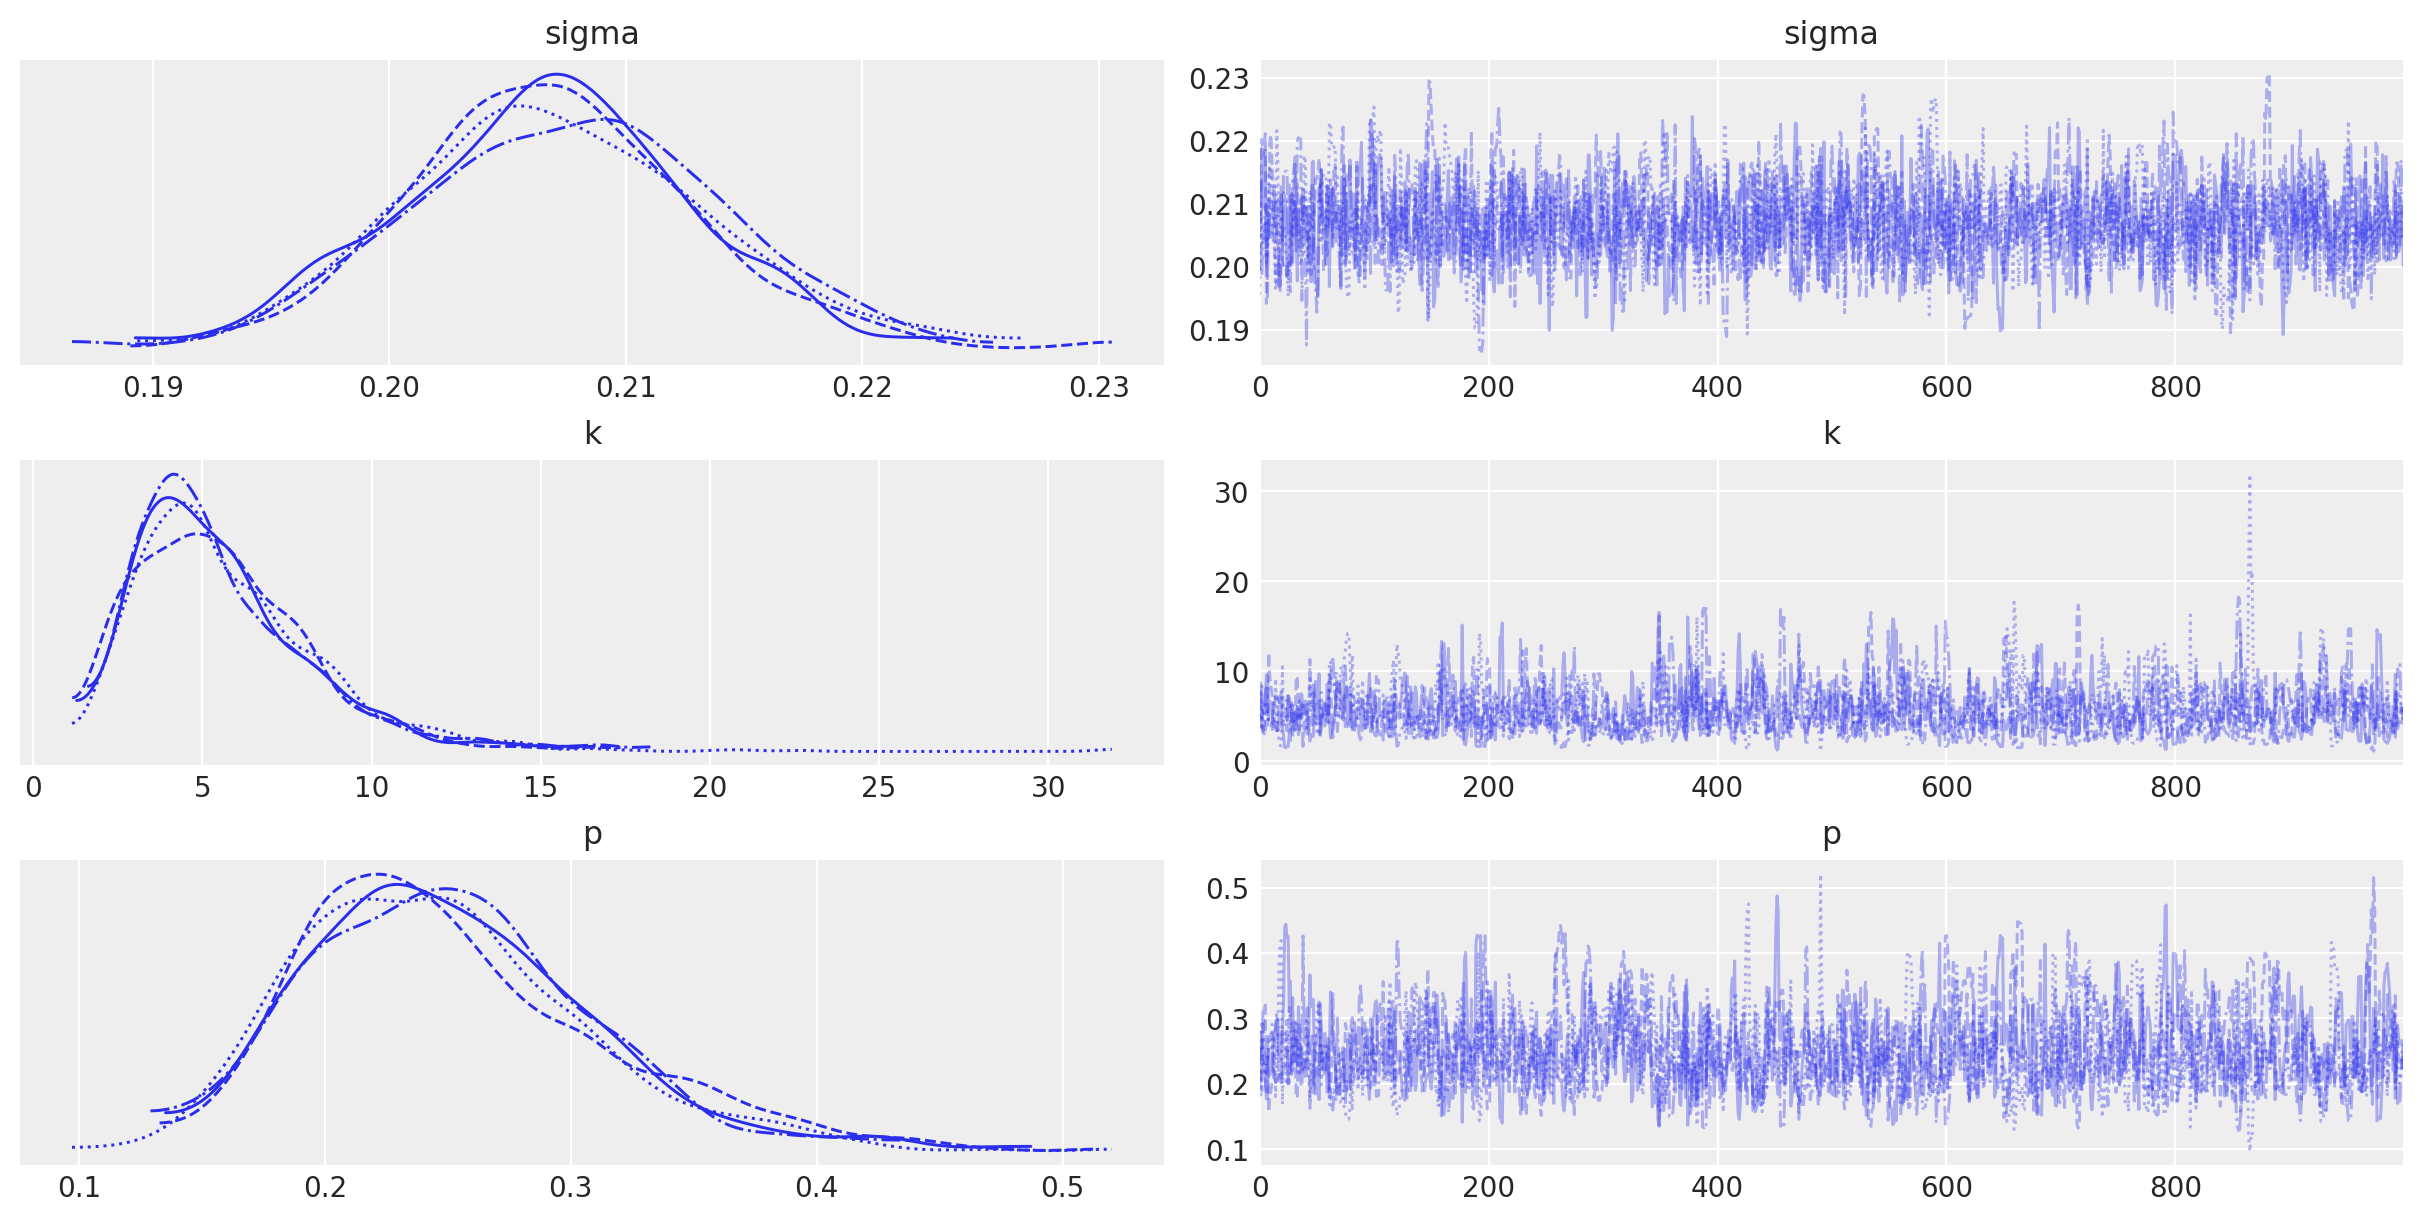

In [9]:
az.plot_trace(trace_16_1, varnames);

The divergences/warnings give us a clue that something in the model isn't working very well. The book explores this through the pairs plot of `k` and `p`

In [10]:
trace_16_1.posterior

<xarray.Dataset> Size: 18MB
Dimensions:   (chain: 4, draw: 1000, mu_dim_0: 544)
Coordinates:
  * chain     (chain) int64 32B 0 1 2 3
  * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * mu_dim_0  (mu_dim_0) int64 4kB 0 1 2 3 4 5 6 ... 537 538 539 540 541 542 543
Data variables:
    sigma     (chain, draw) float64 32kB 0.2107 0.2142 0.2092 ... 0.2049 0.2072
    k         (chain, draw) float64 32kB 5.435 3.835 5.379 ... 6.025 5.277 5.685
    p         (chain, draw) float64 32kB 0.2352 0.2801 0.2383 ... 0.237 0.2306
    mu        (chain, draw, mu_dim_0) float64 17MB 0.2226 -0.02586 ... 0.3631
Attributes:
    created_at:                 2025-07-16T05:44:12.857286+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.23.0
    sampling_time:              9.19719934463501
    tuning_steps:               1000

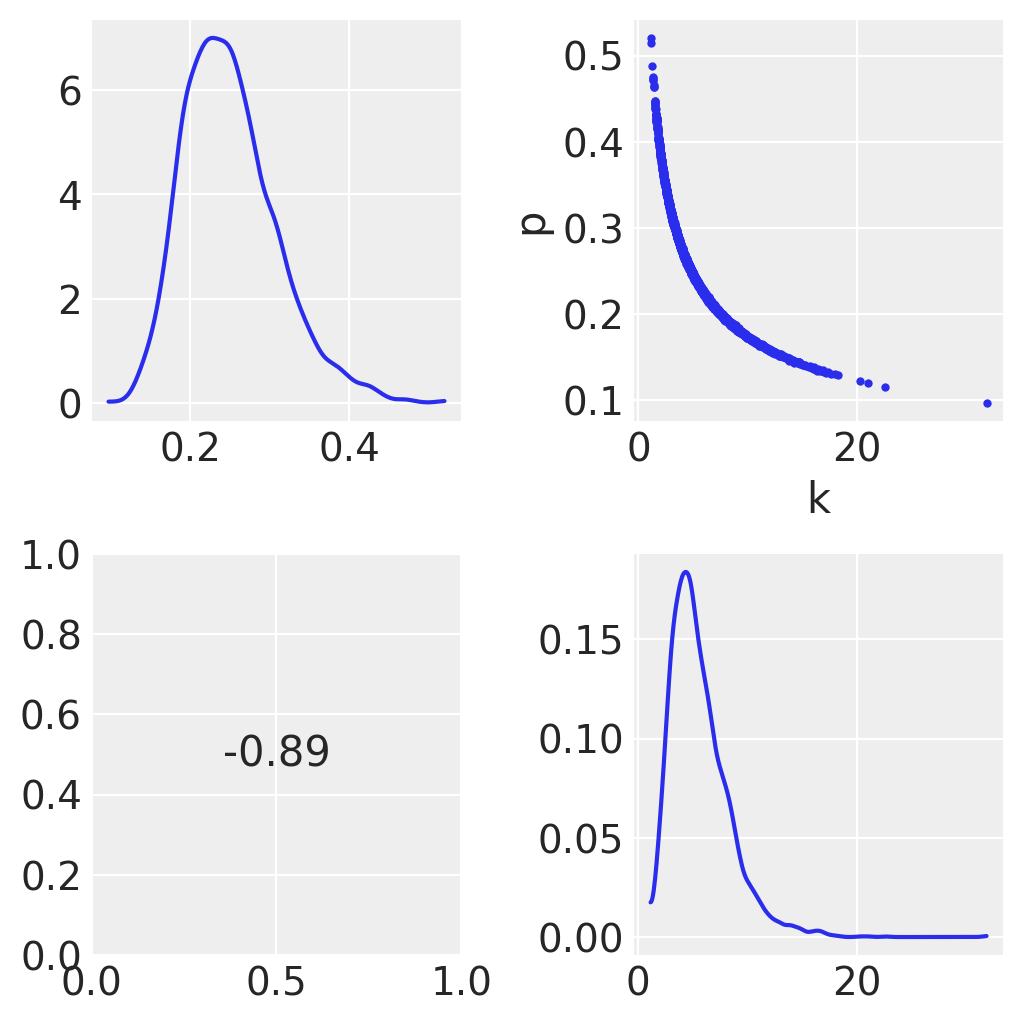

In [11]:
# Replicates Fig 16.2 (left) in the text
_, axes = plt.subplots(2, 2, figsize=(5, 5))
az.plot_kde(trace_16_1.posterior["p"].values.ravel(), ax=axes[0, 0])
az.plot_pair(trace_16_1, var_names=["k", "p"], kind="scatter", ax=axes[0, 1])
az.plot_kde(trace_16_1.posterior["k"].values.ravel(), ax=axes[1, 1])
corr = np.corrcoef(trace_16_1.posterior["p"].values.ravel(), trace_16_1.posterior["k"].values.ravel())[0, 1]
axes[1, 0].text(
    0.5,
    0.5,
    f"{corr:.2f}",
    fontsize=15,
    verticalalignment="center",
    horizontalalignment="center",
);

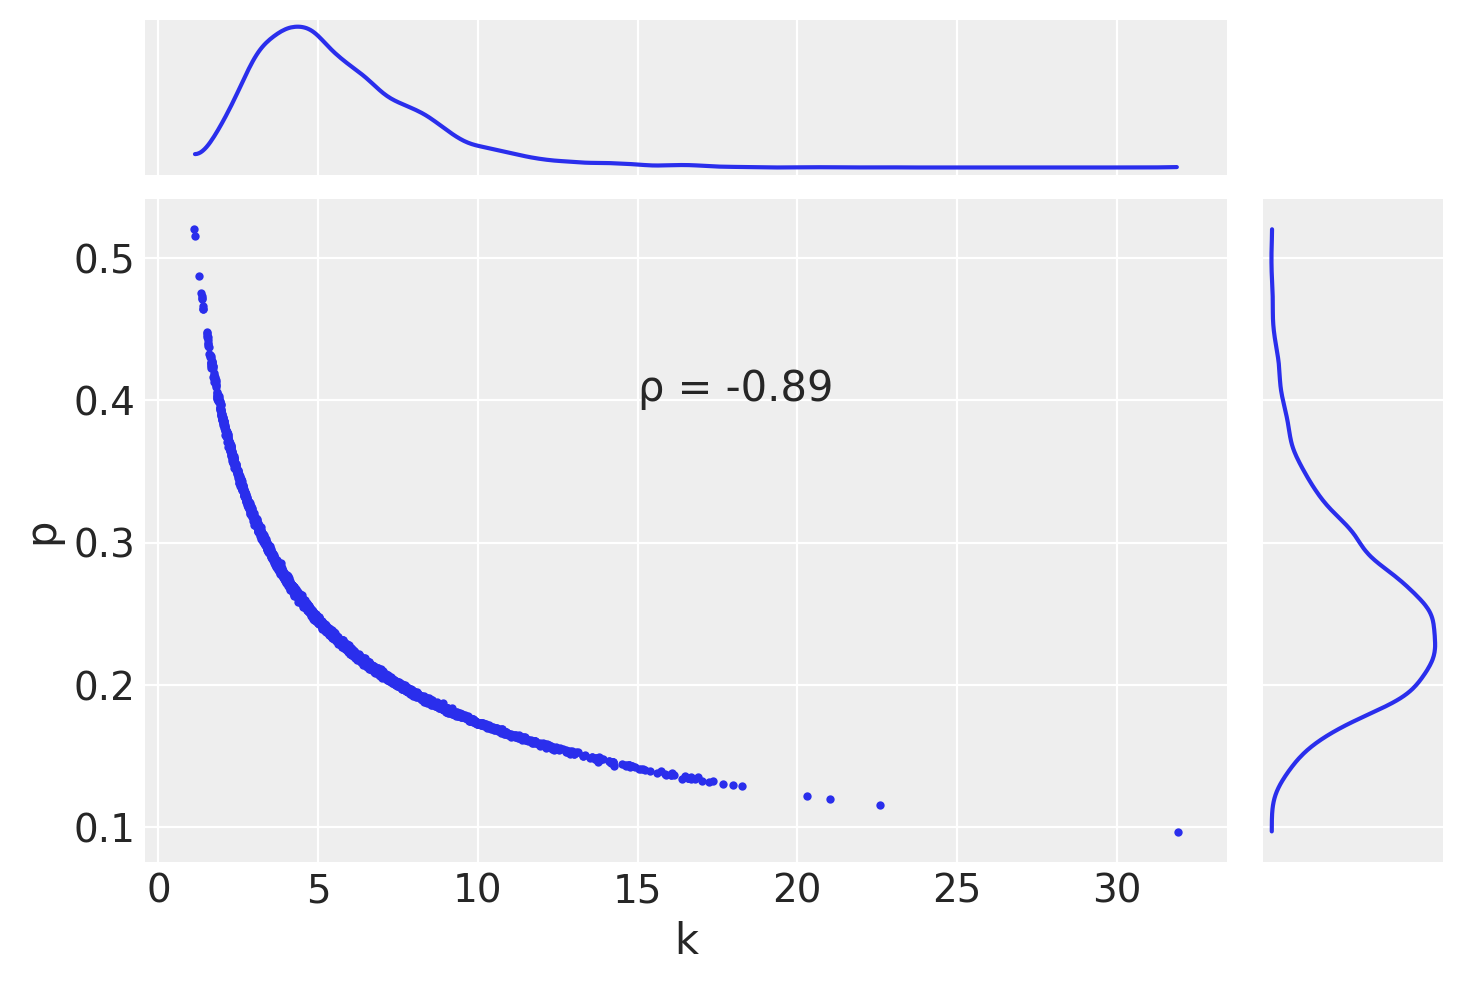

In [12]:
# A more native pymc/Arviz representation
axes = az.plot_pair(trace_16_1, var_names=["k", "p"], kind="scatter", marginals=True)
corr = np.corrcoef(trace_16_1.posterior["p"].values.ravel(), trace_16_1.posterior["k"].values.ravel())[0, 1]
axes[1, 0].text(15, 0.4, f"ρ = {corr:.2f}", fontsize=15);

The narrow curved ridge is caused by combinations of `p` and `k` where the product $kp^2$ is a constant.

#### Code 16.3

It is possible to draw the hpd for the entire range of `h_seq` below, by manually resampling the model from the Lognormal distribution, but here we are satisfied with the _Arviz_ hpd region which covers the range of the data.

In [13]:
w_sim = pm.sample_posterior_predictive(trace_16_1, m16_1)
h_seq = np.linspace(0, d.h.max(), 30)
mu_mean = np.pi * (trace_16_1.posterior["k"].values.ravel() * trace_16_1.posterior["p"].values.ravel() ** 2).mean() * h_seq**3

Sampling: [w]


Output()

In [14]:
w_sim.posterior_predictive

<xarray.Dataset> Size: 17MB
Dimensions:  (chain: 4, draw: 1000, w_dim_0: 544)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * w_dim_0  (w_dim_0) int64 4kB 0 1 2 3 4 5 6 7 ... 537 538 539 540 541 542 543
Data variables:
    w        (chain, draw, w_dim_0) float64 17MB 1.548 0.5432 ... 0.1457 1.484
Attributes:
    created_at:                 2025-07-16T05:44:15.279716+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.23.0

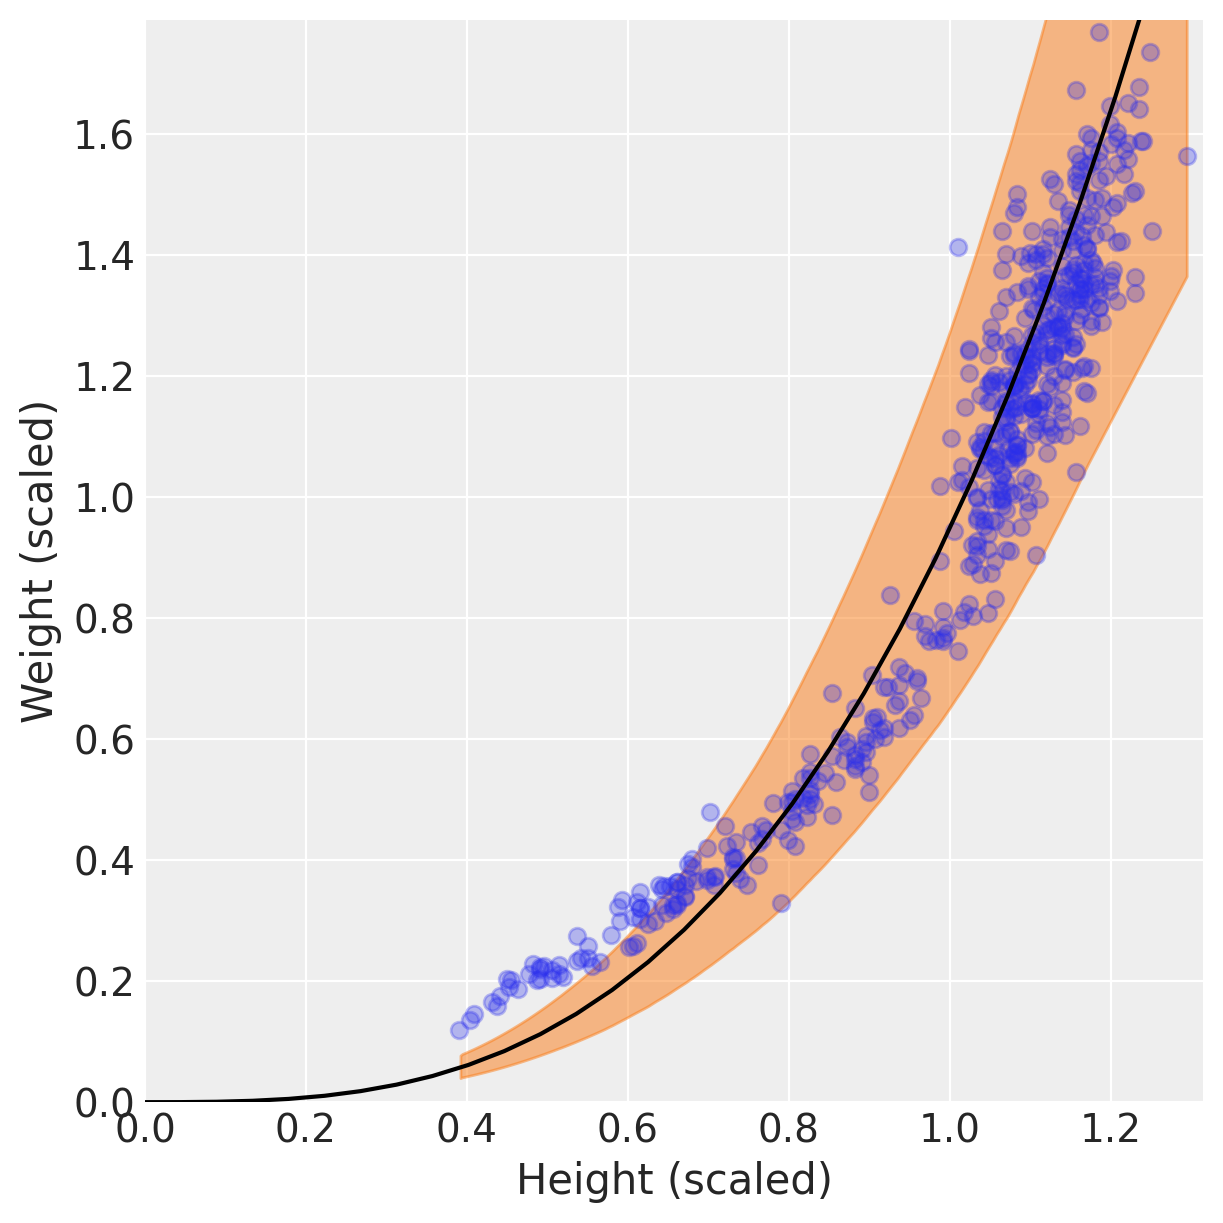

In [15]:
# Fig 16.2 (right) in the text
_, ax = plt.subplots(figsize=(6, 6))
az.plot_hdi(d.h, w_sim.posterior_predictive["w"], ax=ax)
ax.scatter(d.h, d.w, c="C0", alpha=0.3)
ax.plot(h_seq, mu_mean, "k")
ax.set_xlim([0, d.h.max() + 0.02])
ax.set_ylim([0, d.w.max() + 0.02])
ax.set_xlabel("Height (scaled)")
ax.set_ylabel("Weight (scaled)");

Note there seems to be an error in Figure 16.2 of the book, as the axes limits are unit-scaled, whereas the mean of the data should appear at coordinates 1.0.

#### Code 16.4

In [16]:
df = pd.read_csv("Data/Boxes.csv", delimiter=";")
df.describe()

,y,gender,age,majority_first,culture
count,629.000000,629.000000,629.000000,629.000000,629.000000
mean,2.120827,1.505564,8.030207,0.484897,3.751987
std,0.727986,0.500367,2.497906,0.500170,1.960319
min,1.000000,1.000000,4.000000,0.000000,1.000000
25%,2.000000,1.000000,6.000000,0.000000,3.000000
50%,2.000000,2.000000,8.000000,0.000000,3.000000
75%,3.000000,2.000000,10.000000,1.000000,5.000000
max,3.000000,2.000000,14.000000,1.000000,8.000000


#### Code 16.5

In [17]:
df["y"].value_counts(normalize=True, sort=False)

y
1    0.211447
3    0.332273
2    0.456280
Name: proportion, dtype: float64

#### Code 16.6

In [18]:
N = 30  # number of children

# half are random
# sample from 1, 2, 3 at random for each
y1 = np.random.randint(low=1, high=4, size=N // 2)

y2 = np.full(shape=N // 2, fill_value=2)

y = np.random.permutation(np.hstack((y1, y2)))
np.sum(y == 2) / N

np.float64(0.6333333333333333)

#### Code 16.7

In [28]:
# def StrategyMixture(p, majority_first):
#     def logp(y):
#         phi = [None] * 5

#         # Probability of data
#         phi[0] = tt.switch(tt.eq(y, 2), 1, 0)
#         phi[1] = tt.switch(tt.eq(y, 3), 1, 0)
#         phi[2] = tt.switch(tt.eq(y, 1), 1, 0)
#         phi[3] = tt.ones_like(y) * 1 / 3
#         phi[4] = tt.switch(
#             tt.eq(majority_first, 1), tt.switch(tt.eq(y, 2), 1, 0), tt.switch(tt.eq(y, 3), 1, 0)
#         )

#         # Compute log ( p_s * Pr(y_i|s) )
#         for i in range(5):
#             phi[i] = tt.log(phi[i]) + tt.log(p[i])

#         # Compute average log-probability of y_i
#         return tt.sum(pm.math.logsumexp(phi, axis=0))

#     return logp


# with pm.Model() as m16_2:
#     # prior
#     p = pm.Dirichlet("p", np.array([4, 4, 4, 4, 4]))

#     # likelihood
#     # y = pm.DensityDist("y", StrategyMixture(p, df["majority_first"]), observed=df["y"])
#     def logp_fn(value):
#         return StrategyMixture(p, df["majority_first"])
    
#     y = pm.DensityDist("y", logp=logp_fn, observed=df["y"])


def strategy_mixture_logp(y, p, majority_first):
    phi = [None] * 5

    # Indicator functions for each strategy
    phi[0] = tt.switch(tt.eq(y, 2), 1, 0)  # always right
    phi[1] = tt.switch(tt.eq(y, 3), 1, 0)  # always left
    phi[2] = tt.switch(tt.eq(y, 1), 1, 0)  # always pull
    phi[3] = tt.ones_like(y) / 3           # random
    phi[4] = tt.switch(
        tt.eq(majority_first, 1),
        tt.switch(tt.eq(y, 2), 1, 0),      # follow majority
        tt.switch(tt.eq(y, 3), 1, 0),      # follow minority
    )

    # Mixture log-likelihood
    phi_log = [tt.log(phi[i]) + tt.log(p[i]) for i in range(5)]
    logp_all = pm.math.logsumexp(tt.stack(phi_log), axis=0)
    return tt.sum(logp_all)


with pm.Model() as m16_2:
    p = pm.Dirichlet("p", np.array([4, 4, 4, 4, 4]))

    # Custom likelihood via potential
    pm.Potential("likelihood", strategy_mixture_logp(df["y"].values, p, df["majority_first"].values))

    m16_2_trace = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


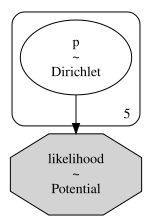

In [29]:
pm.model_to_graphviz(m16_2)

#### Code 16.8

In [30]:
with m16_2:
    m16_2_trace = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


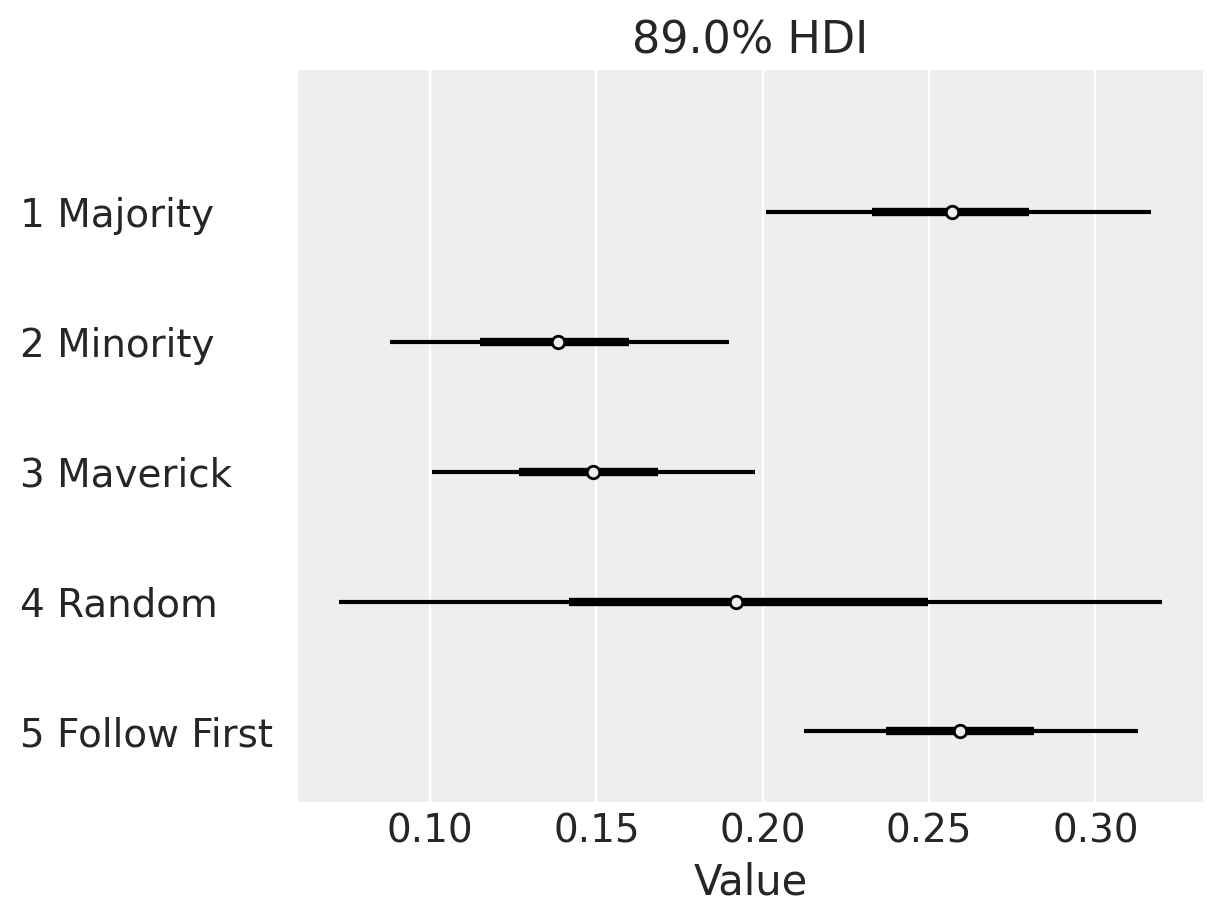

In [31]:
ax = az.plot_forest(m16_2_trace, combined=True, colors="black")

ax = ax[0]
ax.set_yticklabels(
    ["5 Follow First", "4 Random", "3 Maverick", "2 Minority", "1 Majority"], ha="left"
)
ax.get_yaxis().set_tick_params(pad=100)
ax.set_xlabel("Value");

## Population

In [3]:
POPULATION = pd.read_csv('End_of_chapter_problems/data/Lynx_Hare.csv', sep=';')
POPULATION

,Year,Lynx,Hare
0,1900,4.0,30.0
1,1901,6.1,47.2
2,1902,9.8,70.2
3,1903,35.2,77.4
4,1904,59.4,36.3
5,1905,41.7,20.6
6,1906,19.0,18.1
7,1907,13.0,21.4
8,1908,8.3,22.0
9,1909,9.1,25.4


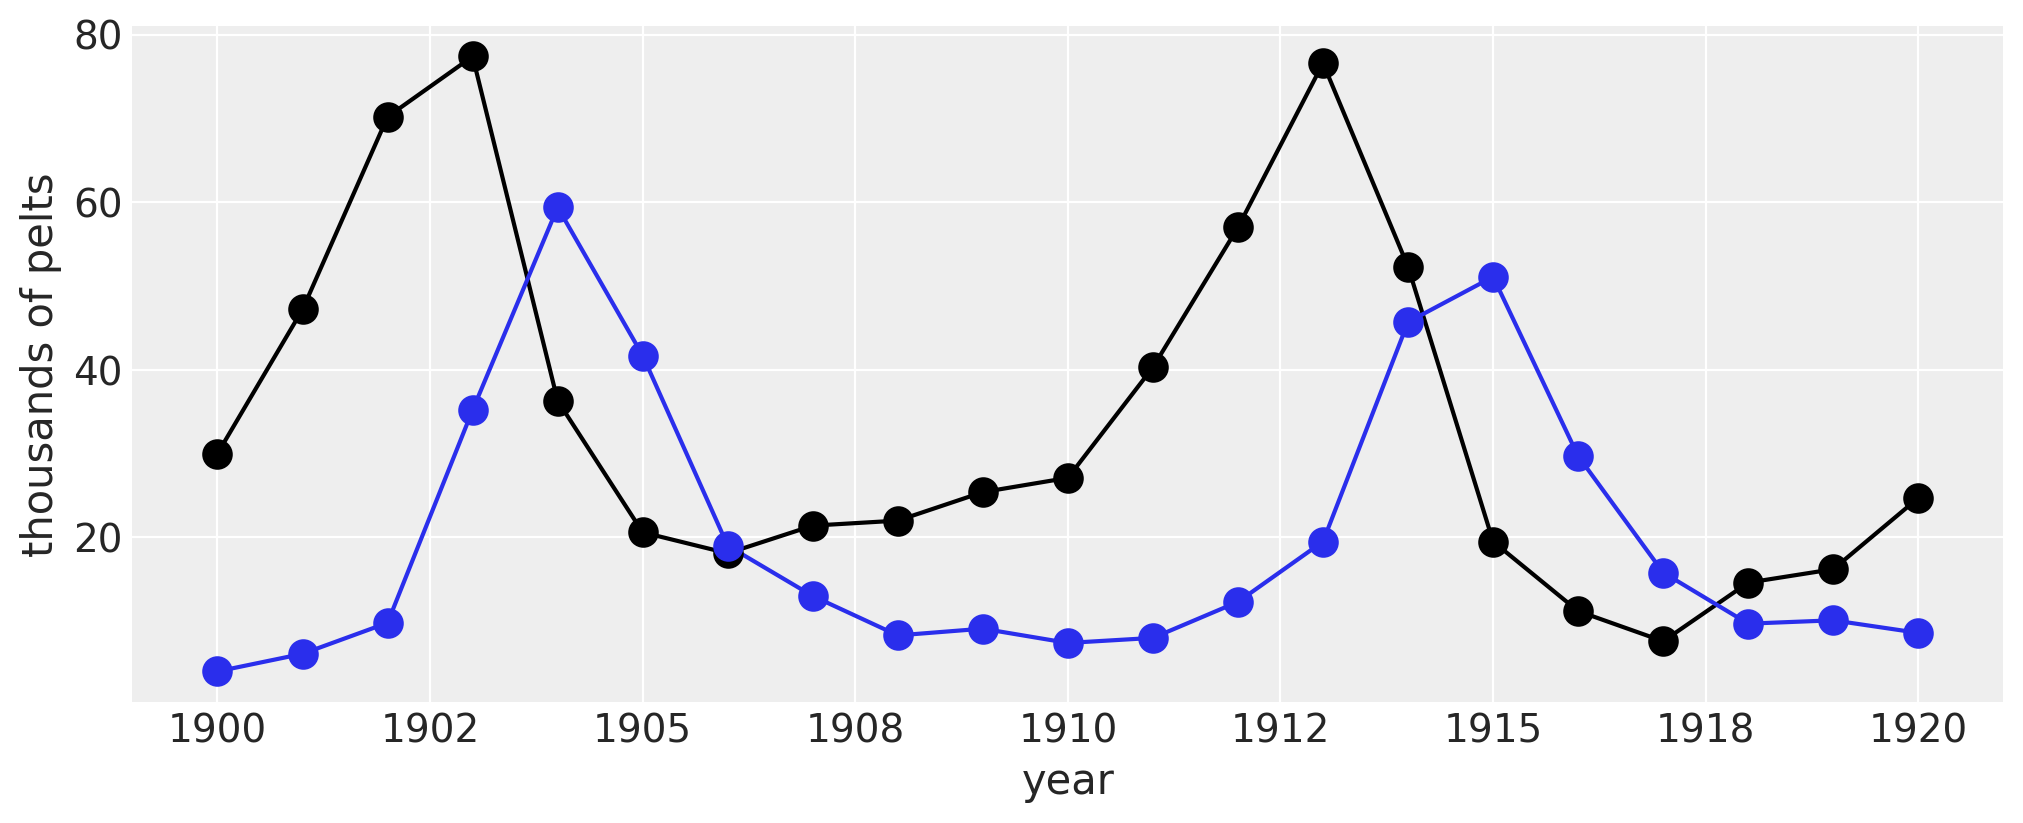

In [4]:
from matplotlib import ticker

def plot_population(data, ax=None):

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    plt.scatter(data.Year, data.Hare, color='k', label="Lepus", zorder=100, s=100)
    plt.plot(data.Year, data.Hare, color='k', label="Lepus")
    
    plt.scatter(data.Year, data.Lynx, color='C0', label="Lynx", zorder=100, s=100)
    plt.plot(data.Year, data.Lynx, color='C0', label="Lynx")

    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
    plt.xlabel("year")
    plt.ylabel("thousands of pelts")

plot_population(POPULATION)

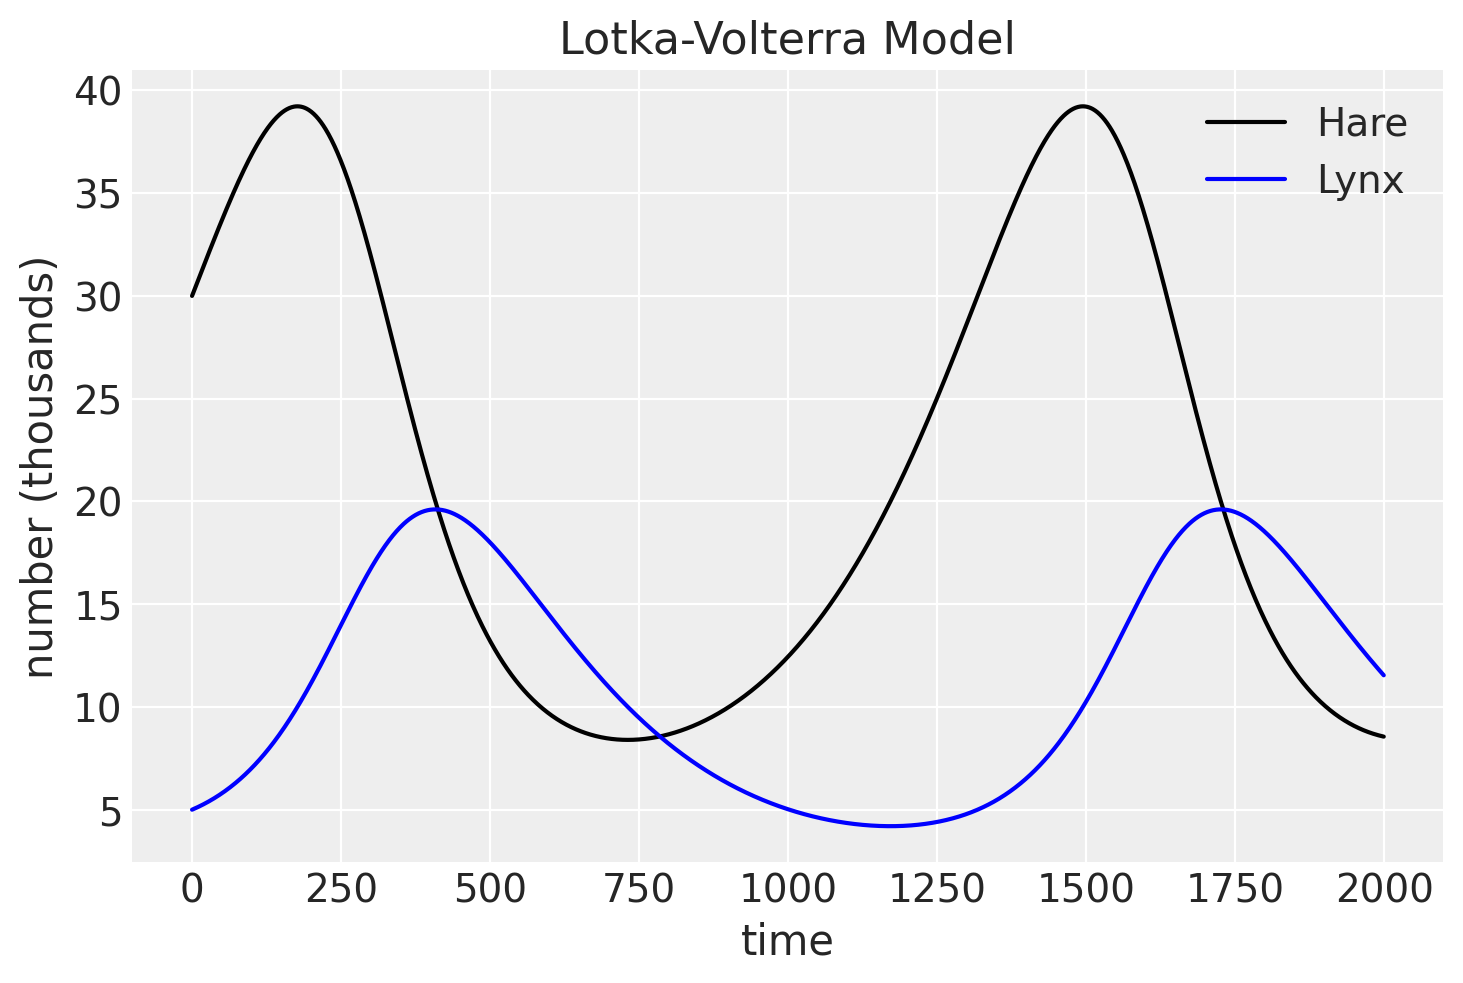

In [5]:
from numba import njit
from scipy.integrate import odeint

@njit
def lotka_volterra_diffeq(X, t, theta):
    # Unpack
    H, L = X
    bH, mH, bL, mL, _, _ = theta
    
    # Diff equations
    dH_dt = H * (bH - mH * L)
    dL_dt = L * (bL * H - mL)
    return [dH_dt, dL_dt]

def simulate_population_dynamics(
    initial_hares=30, 
    initial_lynxes=5,
    birth_rate_hare=.5,
    mortatily_rate_hare=.05,
    birth_rate_lynx=.025,
    mortality_rate_lynx=.5,
    n_time_points=20,
    dt=1
):
    time = np.arange(0, n_time_points, dt)
    theta = np.array(
        [
            birth_rate_hare, mortatily_rate_hare,
            birth_rate_lynx, mortality_rate_lynx,
            initial_hares, initial_lynxes
        ]
    )
    HL = odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=time, args=(theta,))
    return HL[:, 0], HL[:, 1]

# Simulation with parameters shown in Figure 16.7 of the book (2nd edition)
hare_population, lynx_population = simulate_population_dynamics(
    initial_hares=30, 
    initial_lynxes=5,
    birth_rate_hare=.5,
    mortatily_rate_hare=.05,
    birth_rate_lynx=.025,
    mortality_rate_lynx=.5,
    n_time_points=20,
    dt=.01
)
plt.plot(hare_population, color='k', label='Hare')
plt.plot(lynx_population, color='blue', label='Lynx')
plt.xlabel("time")
plt.ylabel("number (thousands)")
plt.legend()
plt.title("Lotka-Volterra Model");

{'initial_hares_population': np.float64(62.46508314413327),
 'initial_lynx_population': np.float64(3.73218341358194),
 'p_trapped_hare': np.float64(0.18755284355997892),
 'p_trapped_lynx': np.float64(0.16310620806753454),
 'initial_hares': np.float64(11.715503966892703),
 'initial_lynxes': np.float64(0.6087422844018971),
 'birth_rate_hare': np.float64(0.5219090844879641),
 'mortality_rate_hare': np.float64(0.11569323766813411),
 'birth_rate_lynx': np.float64(0.07386090151797514),
 'mortality_rate_lynx': np.float64(0.9423111902497923),
 'hare_population': array([19.63817095, 29.19826078, 28.23651683, 50.71810838, 19.84793473,
         7.47923655,  4.24935002,  5.73155482,  6.39410051,  7.5552296 ,
        15.60151539, 28.22202333, 31.82844508, 39.9041958 , 31.36096064,
        13.88083494,  7.12609809,  5.41608361,  7.59162182, 10.5313164 ]),
 'lynx_population': array([ 0.83884324,  0.77317152,  2.46052459,  9.07240807, 20.22343338,
        14.06319061,  8.45831069,  4.3774741 ,  1.9568

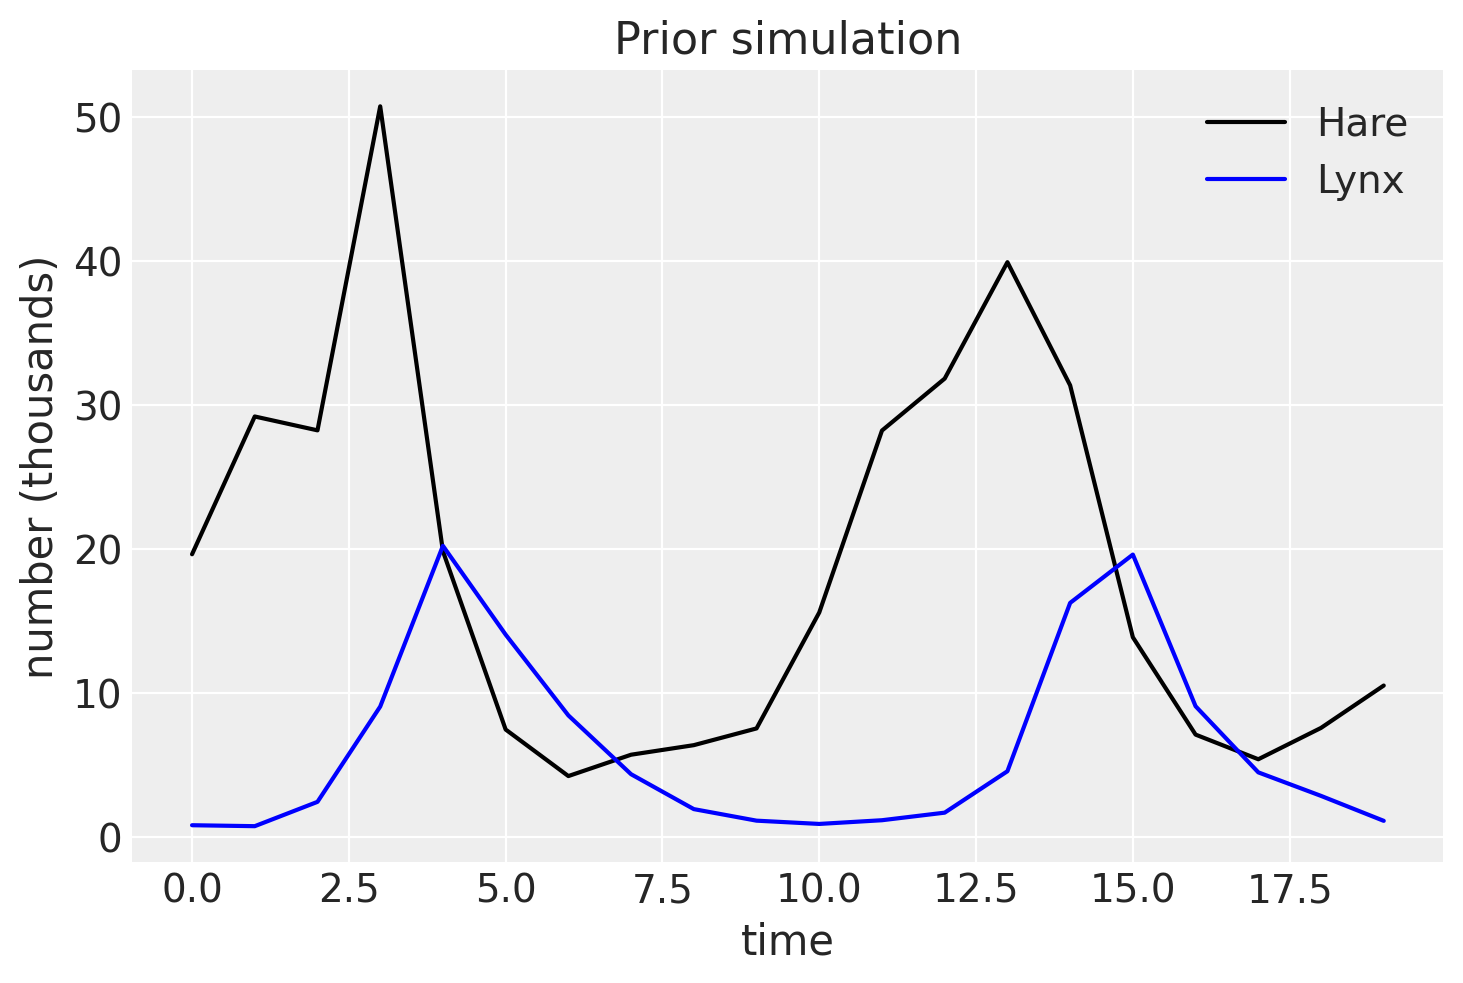

In [9]:
#prior predictive simulation
def sample_prior(random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    # Initial population
    population_prior = stats.lognorm(np.log(10), 1)
    initial_hares_population = population_prior.rvs()
    initial_lynx_population = population_prior.rvs()

    # Observation model, probability of getting trapped
    trapped_prior = stats.beta(40, 200)
    p_trapped_hare = trapped_prior.rvs()
    p_trapped_lynx = trapped_prior.rvs()
    
    initial_hares =  initial_hares_population * p_trapped_hare
    initial_lynxes = initial_lynx_population * p_trapped_lynx

    # Birth/mortality rates
    birth_rate_hare = stats.halfnorm(.5, 0.5).rvs()
    birth_rate_lynx = stats.halfnorm(0.05, 0.05).rvs()
    
    mortality_rate_hare = stats.halfnorm(0.05, 0.05).rvs()    
    mortality_rate_lynx = stats.halfnorm(.5, 0.5).rvs()

    hare_population, lynx_population = simulate_population_dynamics(
        initial_hares,
        initial_lynxes,
        birth_rate_hare,
        mortality_rate_hare,
        birth_rate_lynx,
        mortality_rate_lynx,
        n_time_points=20,
        dt=1
    )

    # Multiplicative noise
    hare_population *= (1 + np.random.rand(len(hare_population)))
    lynx_population *= (1 + np.random.rand(len(lynx_population)))
    
    plt.plot(hare_population, color='k', label='Hare')
    plt.plot(lynx_population, color='blue', label='Lynx')
    plt.xlabel("time")
    plt.ylabel("number (thousands)")
    plt.title("Prior simulation")
    plt.legend()

    return {
        "initial_hares_population": initial_hares_population,
        "initial_lynx_population": initial_lynx_population,
        "p_trapped_hare": p_trapped_hare,
        "p_trapped_lynx": p_trapped_lynx,
        "initial_hares": initial_hares, 
        "initial_lynxes": initial_lynxes,
        "birth_rate_hare": birth_rate_hare,
        "mortality_rate_hare": mortality_rate_hare,
        "birth_rate_lynx": birth_rate_lynx,
        "mortality_rate_lynx": mortality_rate_lynx,
        "hare_population": hare_population,
        "lynx_population": lynx_population
    }


prior_samples = sample_prior(random_seed=3);
SIMULATED_POPULATION = pd.DataFrame(
    {
        "Year": np.arange(1900, 1900 + len(prior_samples['hare_population'])),
        "Hare": prior_samples['hare_population'],
        "Lynx": prior_samples['lynx_population'],
    }
)
prior_samples

PyMC implementation details
PyMC has a built-in ODE solver, but the docs for that solver warn that it's pretty slow, and recommends that we use Sunode ODE Solver. AFAICT, at this point in time, the sunode solver isn't available for Mac M1 (i.e. it's not available on conda-forge, and installing from source is a bit of a mess on ARM64 chipset).

Indeed, I was finding the built-in ODE solver in PyMC (pm.ode.DifferentialEquation) prohibitive for building and debugging models (it was taking over an hour per model to sample; quite difficult to iterate at that pace). As an alternative approach, I'm using the implementation outlined in Lotke-Volterra examples in the PyMC docs. The approach is to wrap scipy's odeint function using Pytensor's as_op decorator so that variable input/output types are available via PyMC. This allows us to to use non-gradient based samplers (e.g. Slice sampler), which are a lot more forgiving to exotic models like ones that embed ODE integration.

⚠️ These models are super-sensitive to starting conditions, and I wasn't able to get the models to converge using the priors suggested in lecture. Instead, we perform an initial least-squares fit to the data, and inform our priors using the resulting least squares parameter estimates.

In [24]:
# Plotting helpers
def plot_data(data):
    plt.scatter(data.Year, data.Hare, color='k', zorder=100, alpha=1)
    plt.scatter(data.Year, data.Lynx, color='blue', zorder=100, alpha=1)

def plot_model_trace(inference_df, row_idx, lw=1, alpha=0.2, label=False):
    
    cols = ["bH", "mH", "bL", "mL", "initial_H", "initial_L"]
    theta = inference_df.loc[row_idx, cols].values
    p_trapped = inference_df.loc[row_idx, ["p_trapped_H", "p_trapped_L"]].values

    time = np.arange(1900, 1921, 0.01)

    # Run dynamics with model params
    HL = odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=time, args=(theta,))
    
    label_H = 'Hare' if label else None
    label_L = 'Lynx' if label else None
    hare_pelts = HL[:, 0] * p_trapped[0]
    lynx_pelts = HL[:, 1] * p_trapped[1]
    plt.plot(time, hare_pelts, color='k', alpha=.1, label=label_H)
    plt.plot(time, lynx_pelts, color='blue', alpha=.1, label=label_L)

def plot_population_model_posterior(
    inference,
    n_samples=25,
    title=None,
    plot_model_kwargs=dict(lw=1, alpha=0.2),
):
    inference_df = inference.posterior.sel(chain=0).to_dataframe()

    for row_idx in range(n_samples):
        label = row_idx == 0
        plot_model_trace(inference_df, row_idx, label=label)

    plt.legend()
    plt.title(title, fontsize=16)

In [17]:
import pytensor.tensor as pt
from pytensor.compile.ops import as_op
from scipy.optimize import least_squares

def fit_lotka_volterra_model(
    data,
    theta_0=None
):
    # Data
    H = data.Hare.values.astype(float)
    L = data.Lynx.values.astype(float)
    TIMES = data.Year.astype(float)

    # Step 0, get informed priors using Least Squares
    def ode_model_residuals(theta):
        # Calculates residuals for Lotka-Volterra model, based on a given state of params
        return (
            data[["Hare", "Lynx"]] - odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=data.Year, args=(theta,))
        ).values.flatten()
    
    # Least squares solution using the scipy's solver    
    theta_0 = np.array([0.5, 0.025, 0.025, 0.75, H[0], L[0]]) if theta_0 is None else theta_0
    lstsq_solution = least_squares(ode_model_residuals, x0=theta_0)

    # Pack solution into a dictionary for more-readable code
    lstsq = {}
    parameter_names = ["bH", "mH", "bL", "mL", "H0", "L0"]
    for k, v in zip(parameter_names, lstsq_solution.x):
        lstsq[k] = v
    print("Initial Least Square Param Estimates:\n", lstsq)

    # Decorate so that input and output have Pytensor types.
    # This allows `odeint` to be available to PyMC as a valid operation
    @as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])
    def pytensor_lotka_volterra_diffeq(theta):
        return odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=TIMES, args=(theta,))

    with pm.Model() as model:

        # Initial population priors
        initial_H = pm.LogNormal('initial_H', np.log(10), 1, initval=lstsq['H0'])
        initial_L = pm.LogNormal('initial_L', np.log(10), 1, initval=lstsq['L0'])

        # Hare param priors
        bH = pm.TruncatedNormal('bH', mu=lstsq['bH'], sigma=.1, lower=0.0, initval=lstsq['bH'])
        mH = pm.TruncatedNormal('mH', mu=lstsq['mH'], sigma=.05, lower=0.0, initval=lstsq['mH'])

        # Lynx param priors
        bL = pm.TruncatedNormal('bL', mu=lstsq['bL'], sigma=.05, lower=0.0, initval=lstsq['bL'])
        mL = pm.TruncatedNormal('mL', mu=lstsq['mL'], sigma=.1, lower=0.0, initval=lstsq['mL'])

        # Run dynamical system with current params/initial pops
        ode_solution = pytensor_lotka_volterra_diffeq(
            pm.math.stack([bH, mH, bL, mL, initial_H, initial_L])
        )

        # Observation model, probability of being trapped
        p_trapped_H = pm.Beta("p_trapped_H", 40, 200)
        p_trapped_L = pm.Beta("p_trapped_L", 40, 200)

        # Measurement error variance
        sigma_H = pm.Exponential('sigma_H', 1)
        sigma_L = pm.Exponential('sigma_L', 1)

        # Hare likelihood
        population_H = ode_solution[:, 0]
        mu_H = pm.math.log(population_H * p_trapped_H)
        pm.LogNormal('H', mu=mu_H, sigma=sigma_H, observed=H)

        # Lynx likelihood
        population_L = ode_solution[:, 1]
        mu_L = pm.math.log(population_L * p_trapped_L)
        pm.LogNormal('L', mu=mu_L, sigma=sigma_L, observed=L)

        step = pm.Metropolis()
        inference = pm.sample(
            step=step,
            draws=1000,
            tune=1000,
            chains=2,
            cores=1,
            progressbar=True
        )

    return model, inference

In [18]:
lv_model_simualted, lt_inference_simulated = fit_lotka_volterra_model(
    SIMULATED_POPULATION,
    theta_0=np.array(
        [
            prior_samples['birth_rate_hare'],
            prior_samples['mortality_rate_hare'],
            prior_samples['birth_rate_lynx'],
            prior_samples['mortality_rate_lynx'],
            prior_samples['initial_hares'],
            prior_samples['initial_lynxes']
        ]
    )
)

Initial Least Square Param Estimates:
 {'bH': np.float64(0.42064348939958135), 'mH': np.float64(0.07341881981215401), 'bL': np.float64(0.06444397533045382), 'mL': np.float64(1.1815145326222858), 'H0': np.float64(17.99748987589768), 'L0': np.float64(0.5758021358658737)}


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [initial_H]
>Metropolis: [initial_L]
>Metropolis: [bH]
>Metropolis: [mH]
>Metropolis: [bL]
>Metropolis: [mL]
>Metropolis: [p_trapped_H]
>Metropolis: [p_trapped_L]
>Metropolis: [sigma_H]
>Metropolis: [sigma_L]


Output()

/tmp/ipykernel_4933/1230420237.py:36: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run 
with full_output = 1 to get quantitative information.
  return odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=TIMES, args=(theta,))

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 36 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


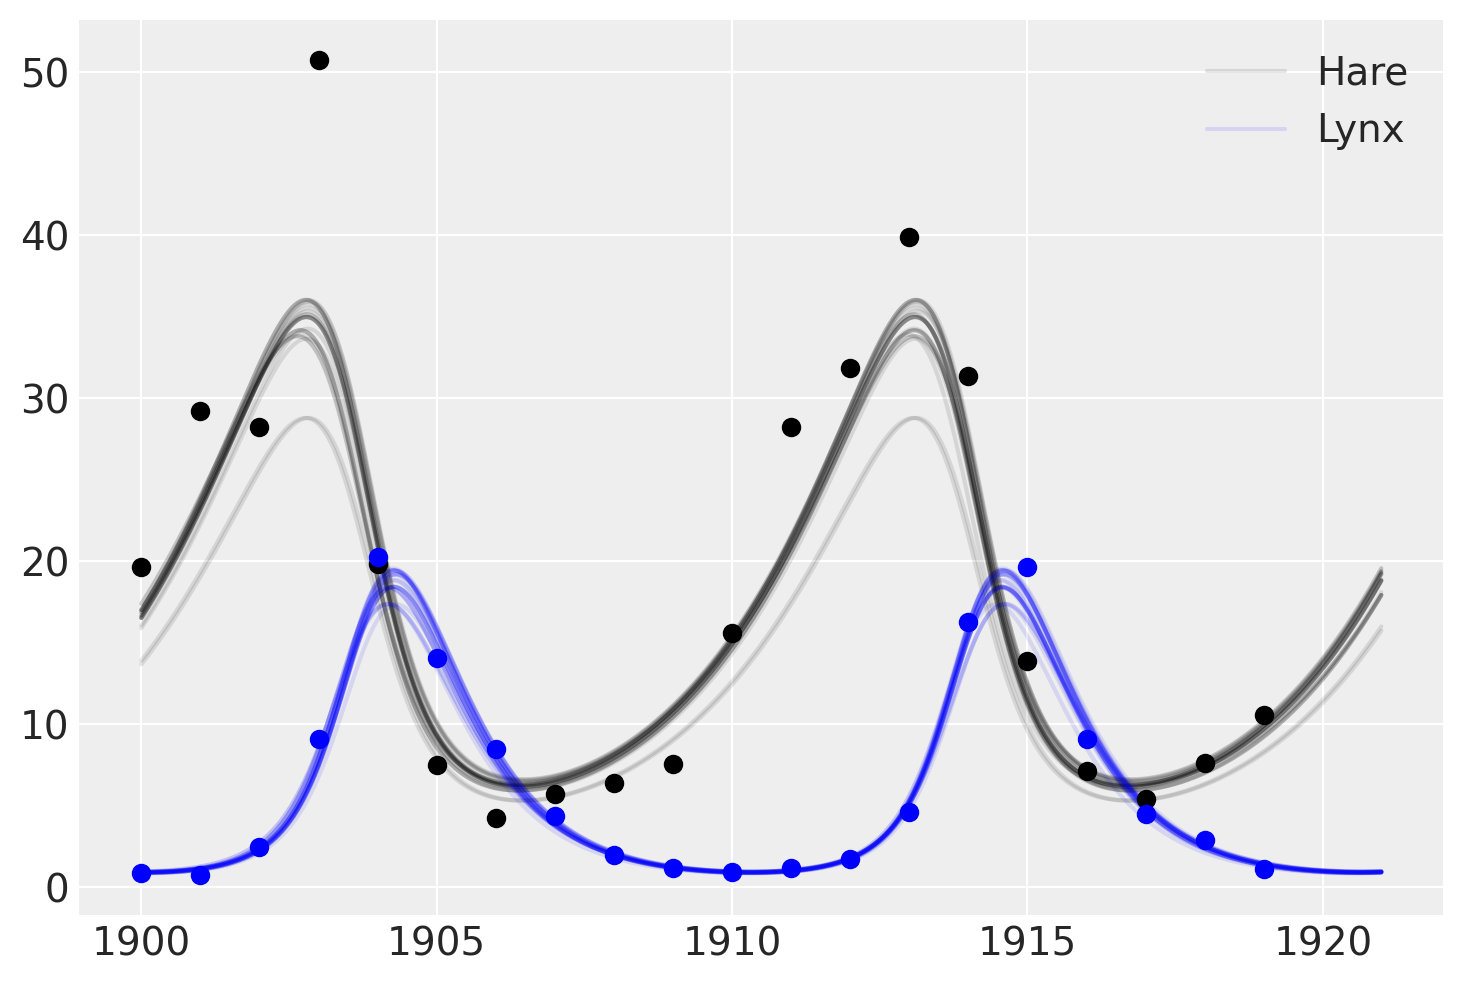

In [25]:
plot_population_model_posterior(lt_inference_simulated)
plot_data(SIMULATED_POPULATION)

### fit model to real data

In [22]:
lv_model, lt_inference = fit_lotka_volterra_model(POPULATION)

Initial Least Square Param Estimates:
 {'bH': np.float64(0.4812016461178473), 'mH': np.float64(0.024831896020904357), 'bL': np.float64(0.027532863458876303), 'mL': np.float64(0.9260141145095272), 'H0': np.float64(34.91413979536395), 'L0': np.float64(3.8618743442444186)}


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [initial_H]
>Metropolis: [initial_L]
>Metropolis: [bH]
>Metropolis: [mH]
>Metropolis: [bL]
>Metropolis: [mL]
>Metropolis: [p_trapped_H]
>Metropolis: [p_trapped_L]
>Metropolis: [sigma_H]
>Metropolis: [sigma_L]


Output()

/tmp/ipykernel_4933/1230420237.py:36: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run 
with full_output = 1 to get quantitative information.
  return odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=TIMES, args=(theta,))

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 28 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#### plot the posterior

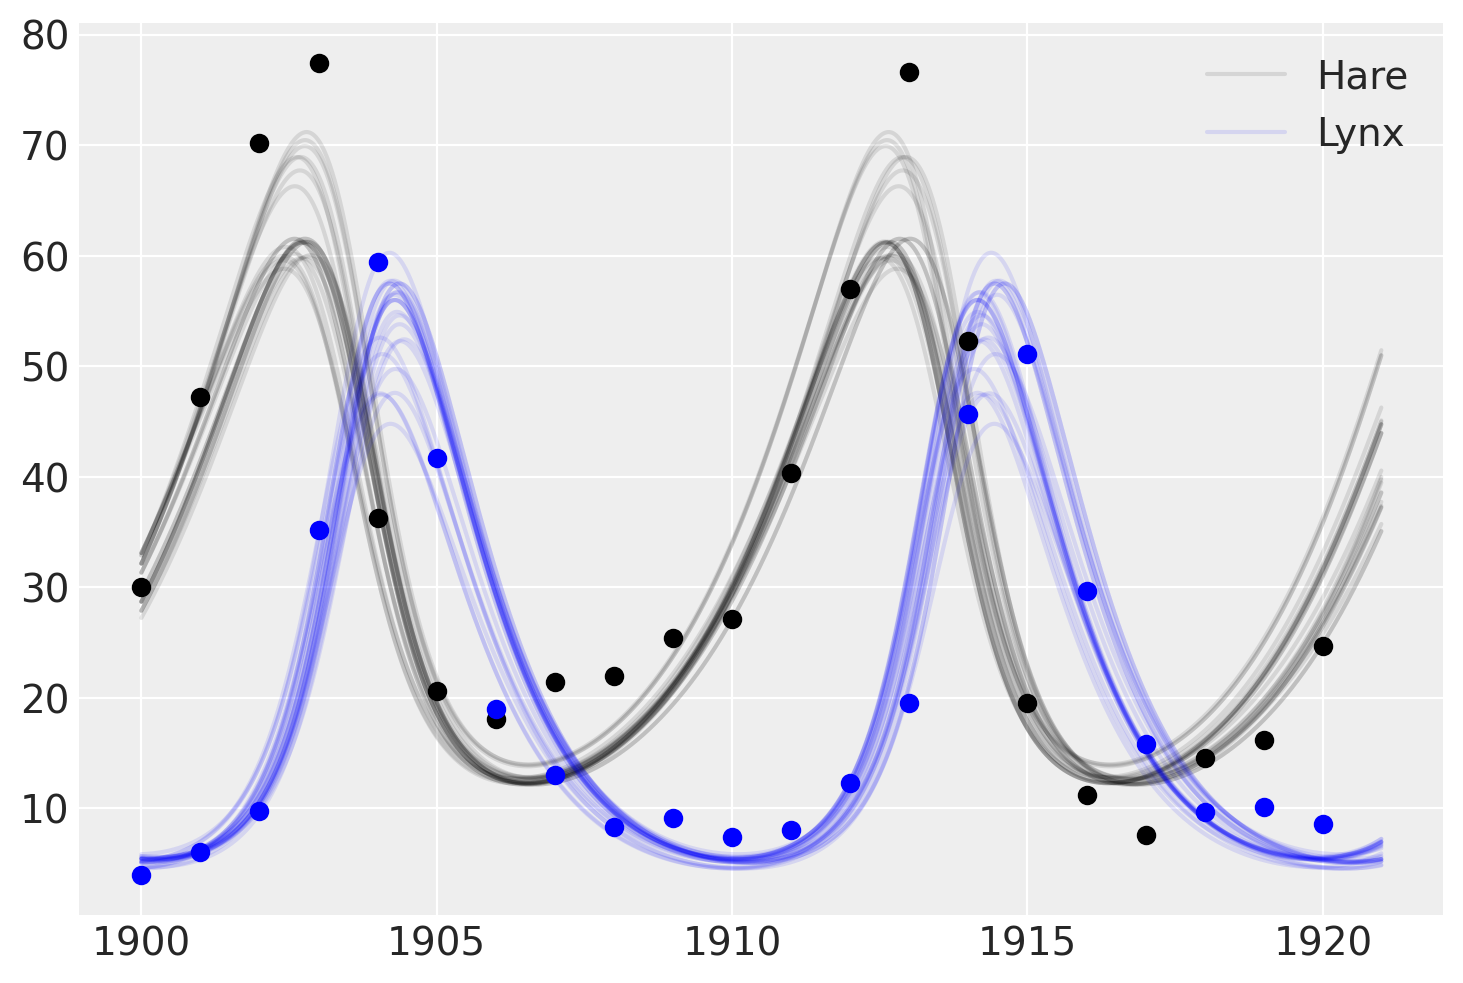

In [26]:
plot_population_model_posterior(lt_inference)
plot_data(POPULATION)

## try with pymc

In [27]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pymc.ode import DifferentialEquation
from scipy.integrate import odeint
from scipy.optimize import least_squares

def lotka_volterra_system(y, t, p):
    H, L = y
    bH, mH, bL, mL = p
    dH = bH * H - mH * H * L
    dL = -mL * L + bL * H * L
    return [dH, dL]

# Pytensor-compatible Lotka-Volterra for pm.ode.DifferentialEquation
def lv_diffeq(y, t, p):
    H = y[0]
    L = y[1]
    bH = p[0]
    mH = p[1]
    bL = p[2]
    mL = p[3]
    dH = bH * H - mH * H * L
    dL = -mL * L + bL * H * L
    return [dH, dL]

def fit_lotka_volterra_model_ode(data, theta_0=None):
    H = data.Hare.values.astype(float)
    L = data.Lynx.values.astype(float)
    TIMES = data.Year.astype(float)

    # Step 0, get informed priors using Least Squares
    def ode_model_residuals(theta):
        return (
            data[["Hare", "Lynx"]] - odeint(func=lotka_volterra_system, y0=theta[-2:], t=TIMES, args=(theta[:4],))
        ).values.flatten()

    theta_0 = np.array([0.5, 0.025, 0.025, 0.75, H[0], L[0]]) if theta_0 is None else theta_0
    lstsq_solution = least_squares(ode_model_residuals, x0=theta_0)

    parameter_names = ["bH", "mH", "bL", "mL", "H0", "L0"]
    lstsq = dict(zip(parameter_names, lstsq_solution.x))
    print("Initial Least Square Param Estimates:\n", lstsq)

    lv_ode = DifferentialEquation(
        func=lv_diffeq,
        times=TIMES,
        n_states=2,
        n_theta=4,
        t0=TIMES[0]
    )

    with pm.Model() as model:
        # Priors
        initial_H = pm.LogNormal('initial_H', mu=np.log(10), sigma=1, initval=lstsq['H0'])
        initial_L = pm.LogNormal('initial_L', mu=np.log(10), sigma=1, initval=lstsq['L0'])

        bH = pm.TruncatedNormal('bH', mu=lstsq['bH'], sigma=0.1, lower=0.0)
        mH = pm.TruncatedNormal('mH', mu=lstsq['mH'], sigma=0.05, lower=0.0)
        bL = pm.TruncatedNormal('bL', mu=lstsq['bL'], sigma=0.05, lower=0.0)
        mL = pm.TruncatedNormal('mL', mu=lstsq['mL'], sigma=0.1, lower=0.0)

        # Solve ODE with symbolic ops
        ode_solution = lv_ode(y0=[initial_H, initial_L], theta=[bH, mH, bL, mL])

        # Observation model
        p_trapped_H = pm.Beta("p_trapped_H", 40, 200)
        p_trapped_L = pm.Beta("p_trapped_L", 40, 200)

        sigma_H = pm.Exponential('sigma_H', 1)
        sigma_L = pm.Exponential('sigma_L', 1)

        mu_H = pm.math.log(ode_solution[:, 0] * p_trapped_H)
        mu_L = pm.math.log(ode_solution[:, 1] * p_trapped_L)

        pm.LogNormal('H', mu=mu_H, sigma=sigma_H, observed=H)
        pm.LogNormal('L', mu=mu_L, sigma=sigma_L, observed=L)

        inference = pm.sample(draws=1000, tune=1000, chains=2, cores=1)

    return model, inference

In [28]:
lv_model_simualted, lt_inference_simulated = fit_lotka_volterra_model(
    SIMULATED_POPULATION,
    theta_0=np.array(
        [
            prior_samples['birth_rate_hare'],
            prior_samples['mortality_rate_hare'],
            prior_samples['birth_rate_lynx'],
            prior_samples['mortality_rate_lynx'],
            prior_samples['initial_hares'],
            prior_samples['initial_lynxes']
        ]
    )
)

Initial Least Square Param Estimates:
 {'bH': np.float64(0.42064348939958135), 'mH': np.float64(0.07341881981215401), 'bL': np.float64(0.06444397533045382), 'mL': np.float64(1.1815145326222858), 'H0': np.float64(17.99748987589768), 'L0': np.float64(0.5758021358658737)}


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [initial_H]
>Metropolis: [initial_L]
>Metropolis: [bH]
>Metropolis: [mH]
>Metropolis: [bL]
>Metropolis: [mL]
>Metropolis: [p_trapped_H]
>Metropolis: [p_trapped_L]
>Metropolis: [sigma_H]
>Metropolis: [sigma_L]


Output()

/tmp/ipykernel_4933/1230420237.py:36: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run 
with full_output = 1 to get quantitative information.
  return odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=TIMES, args=(theta,))

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 31 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [29]:
lv_model, lt_inference = fit_lotka_volterra_model(POPULATION)

Initial Least Square Param Estimates:
 {'bH': np.float64(0.4812016461178473), 'mH': np.float64(0.024831896020904357), 'bL': np.float64(0.027532863458876303), 'mL': np.float64(0.9260141145095272), 'H0': np.float64(34.91413979536395), 'L0': np.float64(3.8618743442444186)}


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [initial_H]
>Metropolis: [initial_L]
>Metropolis: [bH]
>Metropolis: [mH]
>Metropolis: [bL]
>Metropolis: [mL]
>Metropolis: [p_trapped_H]
>Metropolis: [p_trapped_L]
>Metropolis: [sigma_H]
>Metropolis: [sigma_L]


Output()

/tmp/ipykernel_4933/1230420237.py:36: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run 
with full_output = 1 to get quantitative information.
  return odeint(func=lotka_volterra_diffeq, y0=theta[-2:], t=TIMES, args=(theta,))

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 30 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


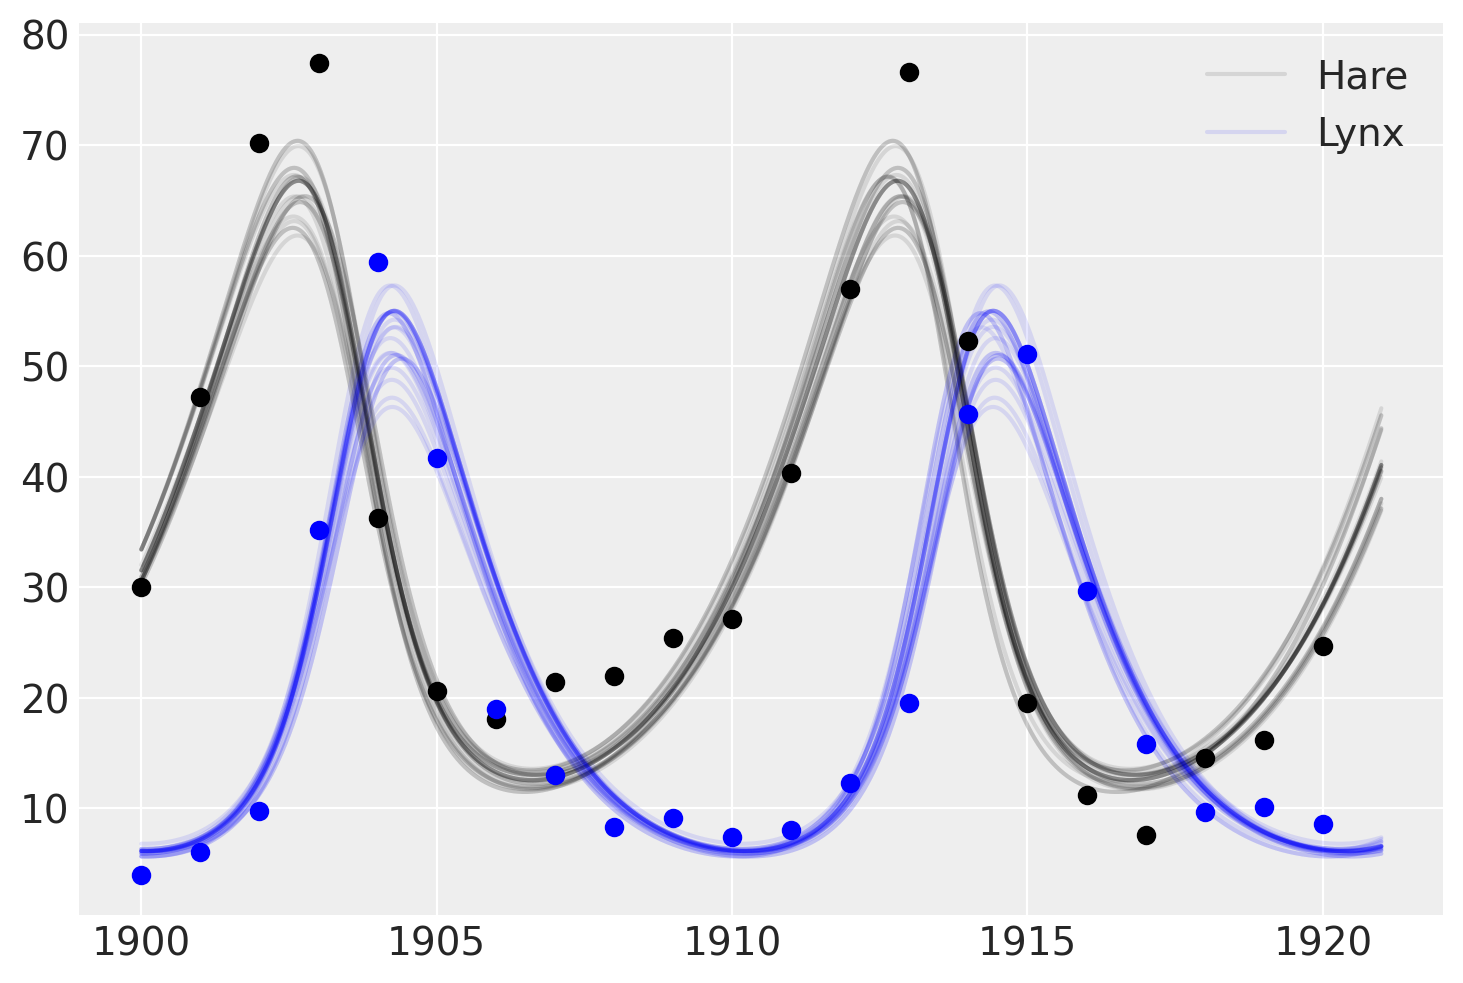

In [30]:
plot_population_model_posterior(lt_inference)
plot_data(POPULATION)

16M1.  Modify the cylinder height model, m16.1, so that the exponent 3 on height is instead a free parameter. Do you recover the value of 3 or not? Plot the posterior predictions for the new model. How do they differ from those of m16.1?

In [42]:
d=pd.read_csv('Data/Howell1.csv', sep=";")
d.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


In [43]:
# Filter adults
d = d[d.age >= 18].copy()

# Scale variables as in Chapter 16
d["h"] = (d.height - d.height.mean()) / d.height.std()
d["w"] = d.weight / d.weight.mean()

In [82]:
with pm.Model() as m16_1:
    sigma = pm.Exponential("sigma", 1)
    k = pm.Exponential("k", 0.5)
    p = pm.Beta("p", 2, 18)
    mu = pm.Deterministic("mu", pm.math.log(np.pi * k * p**2 * d.height.values**3))
    w = pm.Lognormal("w", mu=mu, sigma=sigma, observed=d.weight.values)
    trace_16_1 = pm.sample(return_inferencedata=True,
        idata_kwargs={"log_likelihood": True})


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, k, p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 40 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [76]:
with pm.Model() as m16_1_mod:
    sigma = pm.Exponential("sigma", 1)
    k = pm.Exponential("k", 0.5)
    p = pm.Beta("p", 2, 18)
    e = pm.Normal("e", mu=3, sigma=0.5)  # prior centered on 3
    mu = pm.Deterministic("mu", pm.math.log(np.pi * k * p**2 * d.height.values**e))
    w = pm.Lognormal("w", mu=mu, sigma=sigma, observed=d.weight.values)
    trace_16_1_mod = pm.sample(    return_inferencedata=True,
        idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, k, p, e]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 58 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


<Axes: title={'center': 'e'}>

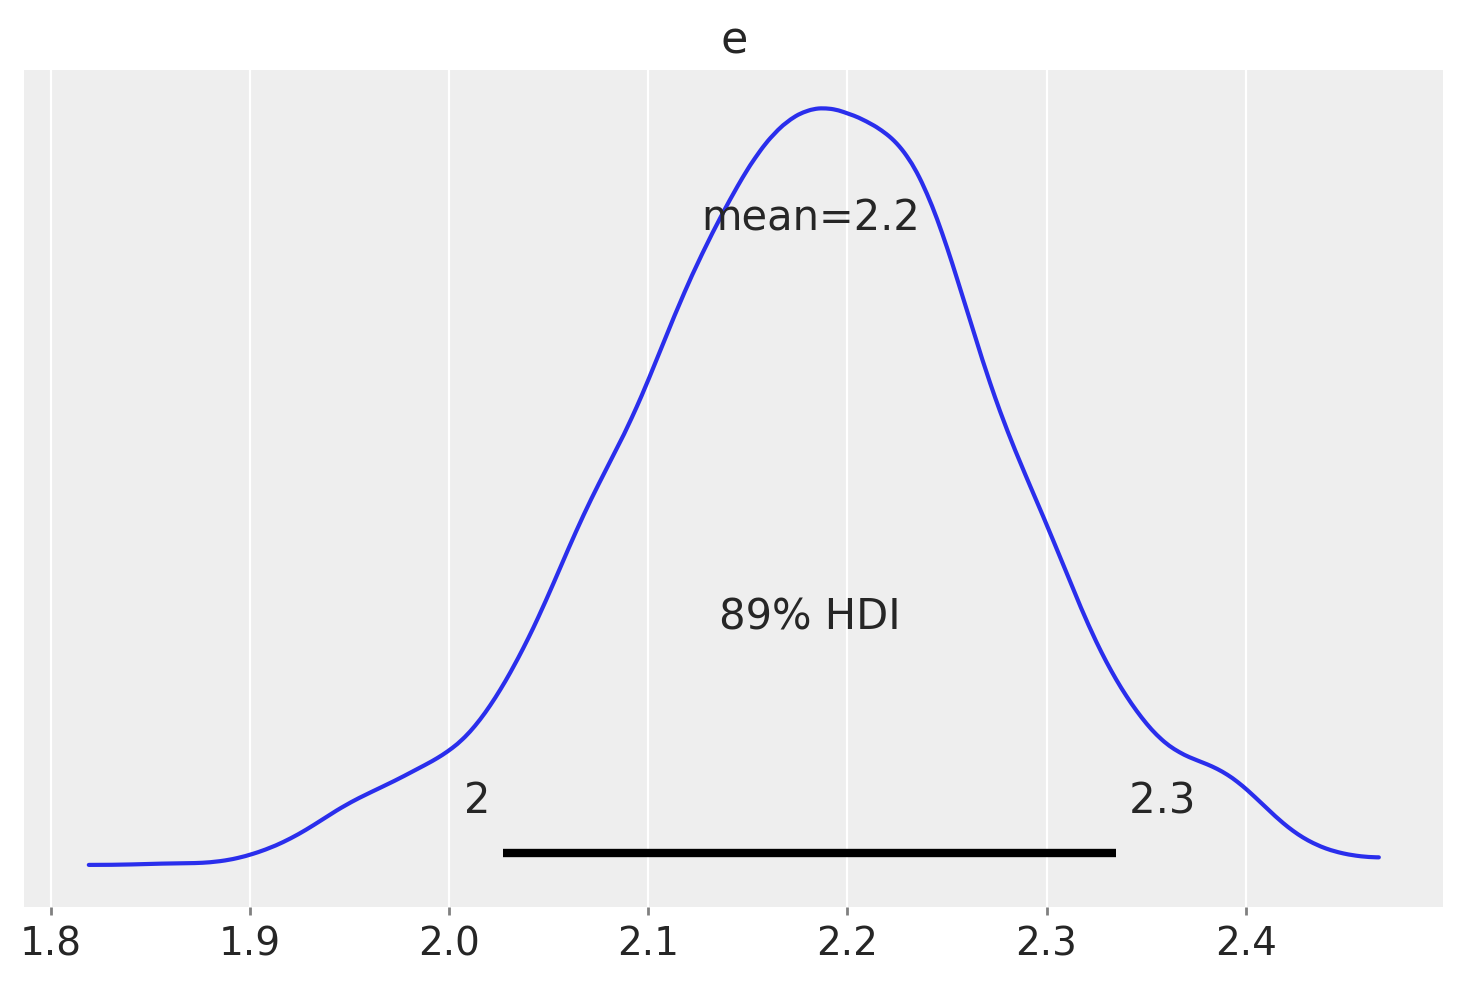

In [50]:
az.plot_posterior(trace_16_1_mod, var_names=["e"])

did not recover 3, it is around 2

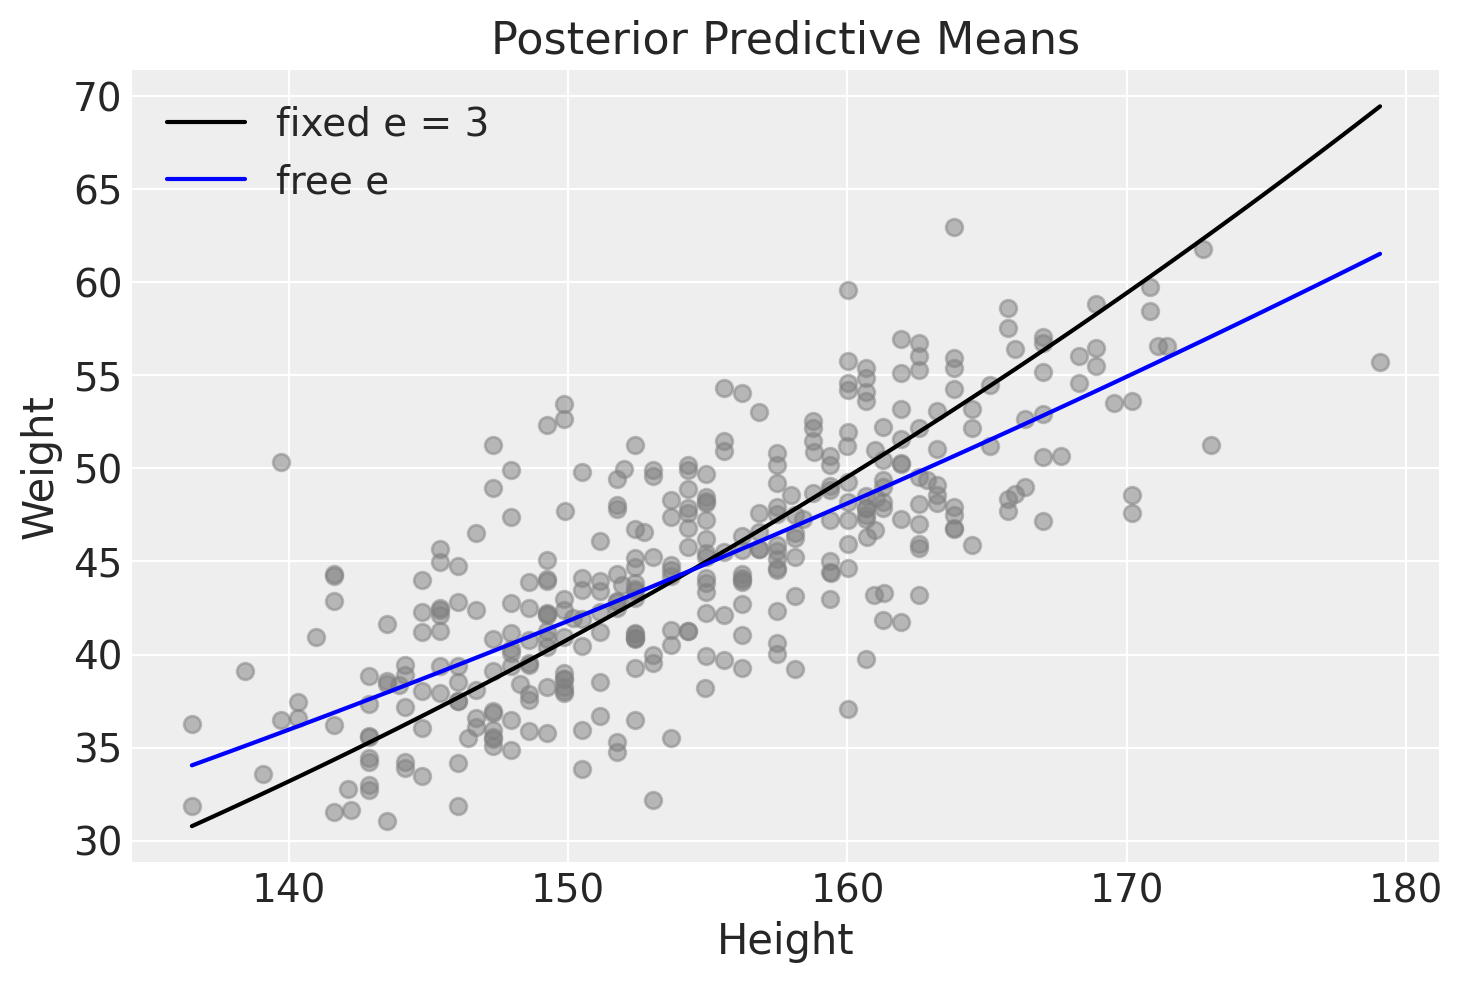

In [62]:
# Create prediction grid
h_seq = np.linspace(d.height.min(), d.height.max(), 100)

# --- Fixed exponent model (e = 3) ---
post_16_1 = trace_16_1.posterior.stack(sample=("chain", "draw"))
k_1 = post_16_1["k"].values  # shape (n_samples,)
p_1 = post_16_1["p"].values  # shape (n_samples,)

# Broadcast prediction across h_seq
mu_16_1 = np.log(np.pi * k_1[:, None] * p_1[:, None]**2 * h_seq[None, :]**3)  # (n_samples, 100)
w_16_1_mean = np.mean(np.exp(mu_16_1), axis=0)

# --- Modified model (free exponent e) ---
post_mod = trace_16_1_mod.posterior.stack(sample=("chain", "draw"))
k_mod = post_mod["k"].values
p_mod = post_mod["p"].values
e_mod = post_mod["e"].values

# Allow variable exponent per sample
mu_mod = np.log(np.pi * k_mod[:, None] * p_mod[:, None]**2 * h_seq[None, :]**e_mod[:, None])
w_mod_mean = np.mean(np.exp(mu_mod), axis=0)

# --- Plot ---
plt.plot(h_seq, w_16_1_mean, label="fixed e = 3", color="black")
plt.plot(h_seq, w_mod_mean, label="free e", color="blue")
plt.scatter(d.height, d.weight, color="gray", alpha=0.5)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Posterior Predictive Means")
plt.legend()
plt.show()

16M2.  Conduct a prior predictive simulation for the cylinder height model. Begin with the priors in the chapter. Do these produce reasonable prior height distributions? If not, which modifications do you suggest?

In [65]:
# Simulate across a grid of heights
h_seq = np.linspace(d.height.min(), d.height.max(), 100)  #  heights

with pm.Model() as prior_model:
    sigma = pm.Exponential("sigma", 1)
    k = pm.Exponential("k", 0.5)
    p = pm.Beta("p", 2, 18)

    # simulate mu for each h in h_seq
    mu_lines = []
    for h in h_seq:
        mu = pm.math.log(np.pi * k * p**2 * h**3)
        mu_lines.append(mu)

    mu_stack = pm.math.stack(mu_lines)
    w = pm.Lognormal("w", mu=mu_stack, sigma=sigma, shape=h_seq.shape[0])

    prior_pred = pm.sample_prior_predictive(samples=100)

Sampling: [k, p, sigma, w]


Text(0.5, 1.0, 'Prior Predictive Simulation')

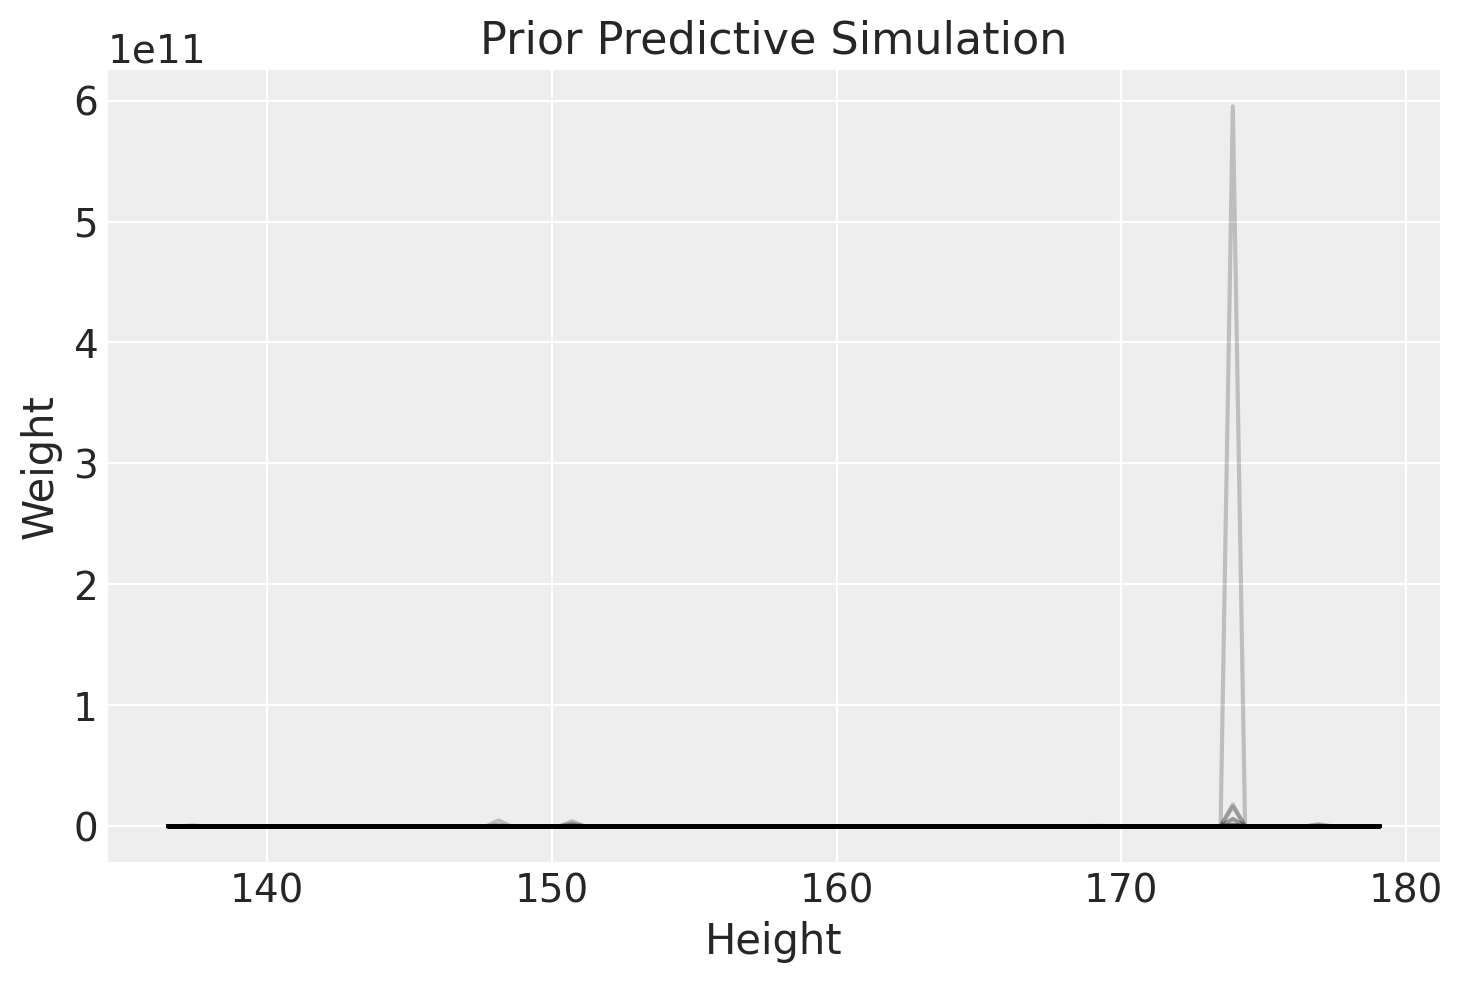

In [66]:
_, ax = plt.subplots()
for i in range(prior_pred.prior["w"].shape[0]):
    ax.plot(h_seq, prior_pred.prior["w"][i], color="k", alpha=0.2)

ax.set_xlabel("Height")
ax.set_ylabel("Weight")
ax.set_title("Prior Predictive Simulation")

widen the priors to make them more flexible

16M3.  Use prior predictive simulations to investigate the lynx-hare model. Begin with the priors in the chapter. Which population dynamics do these produce? Can you suggest any improvements to the priors, on the basis of your simulations?

In [67]:
def prior_predictive_lv_model(TIMES):
    lv_ode = DifferentialEquation(
        func=lv_diffeq,
        times=TIMES,
        n_states=2,
        n_theta=4,
        t0=TIMES[0]
    )

    with pm.Model() as model:
        # Prior distributions from the chapter
        initial_H = pm.LogNormal('initial_H', mu=np.log(10), sigma=1)
        initial_L = pm.LogNormal('initial_L', mu=np.log(10), sigma=1)

        bH = pm.TruncatedNormal('bH', mu=0.5, sigma=0.2, lower=0.0)
        mH = pm.TruncatedNormal('mH', mu=0.025, sigma=0.01, lower=0.0)
        bL = pm.TruncatedNormal('bL', mu=0.025, sigma=0.01, lower=0.0)
        mL = pm.TruncatedNormal('mL', mu=0.75, sigma=0.2, lower=0.0)

        ode_solution = lv_ode(y0=[initial_H, initial_L], theta=[bH, mH, bL, mL])

        pm.Deterministic("hare", ode_solution[:, 0])
        pm.Deterministic("lynx", ode_solution[:, 1])

        prior_pred = pm.sample_prior_predictive(samples=100)

    return prior_pred


TIMES = np.linspace(1900, 1920, 100)
prior_pred = prior_predictive_lv_model(TIMES)


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Sampling: [bH, bL, initial_H, initial_L, mH, mL]


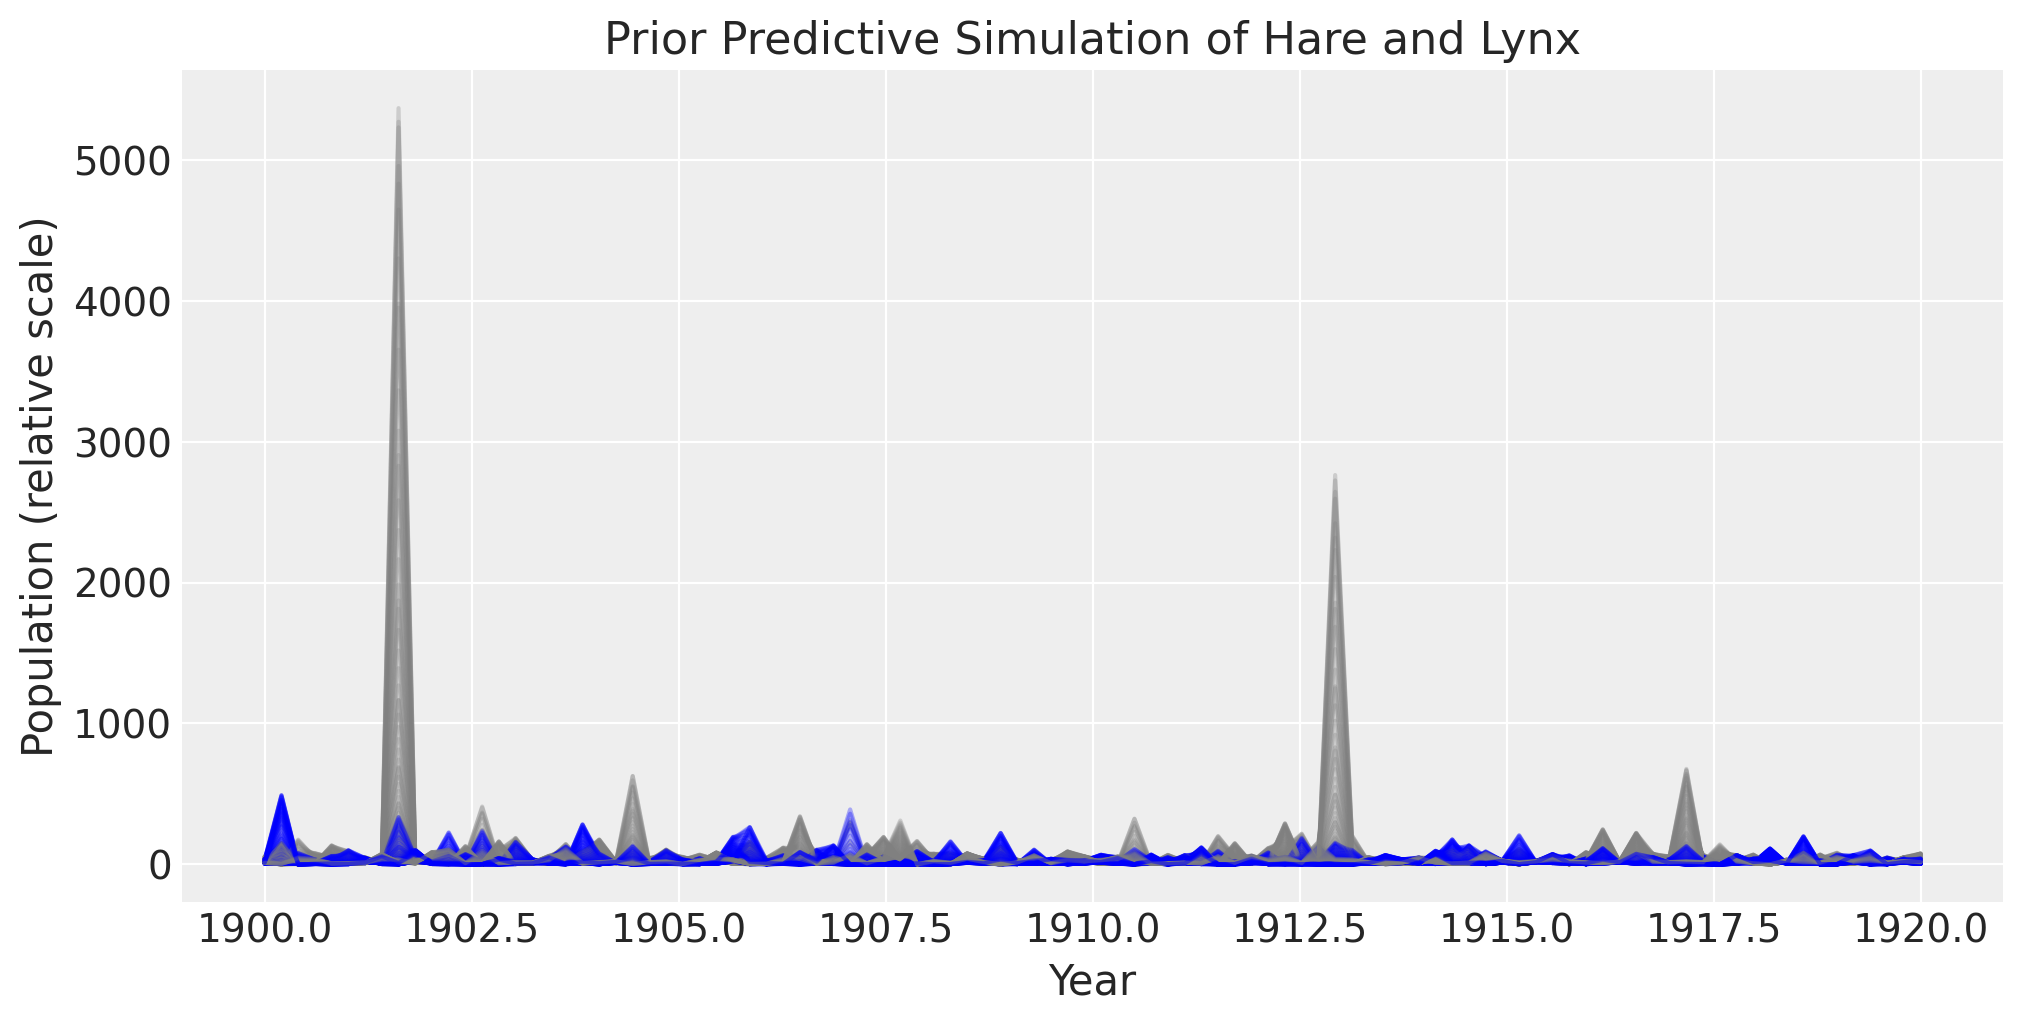

In [68]:
hare = prior_pred.prior["hare"].stack(sample=("chain", "draw")).transpose()
lynx = prior_pred.prior["lynx"].stack(sample=("chain", "draw")).transpose()

_, ax = plt.subplots(figsize=(10, 5))
for i in range(hare.shape[1]):
    ax.plot(TIMES, hare[:, i], color="gray", alpha=0.3)
    ax.plot(TIMES, lynx[:, i], color="blue", alpha=0.3)

ax.set_xlabel("Year")
ax.set_ylabel("Population (relative scale)")
ax.set_title("Prior Predictive Simulation of Hare and Lynx")
plt.show()


Some values are extreme. 

In [70]:


def prior_predictive_lv_model(TIMES):
    lv_ode = DifferentialEquation(
        func=lv_diffeq,
        times=TIMES,
        n_states=2,
        n_theta=4,
        t0=TIMES[0]
    )

    with pm.Model() as model:
        # Prior distributions from the chapter
        initial_H = pm.LogNormal('initial_H', mu=np.log(30), sigma=0.3)  # tighter
        initial_L = pm.LogNormal('initial_L', mu=np.log(4), sigma=0.3)
        
        bH = pm.TruncatedNormal('bH', mu=0.6, sigma=0.05, lower=0.2)  # restrict high growth
        mH = pm.TruncatedNormal('mH', mu=0.03, sigma=0.01, lower=0.005)
        bL = pm.TruncatedNormal('bL', mu=0.03, sigma=0.01, lower=0.005)
        mL = pm.TruncatedNormal('mL', mu=0.7, sigma=0.05, lower=0.5)

        ode_solution = lv_ode(y0=[initial_H, initial_L], theta=[bH, mH, bL, mL])

        pm.Deterministic("hare", ode_solution[:, 0])
        pm.Deterministic("lynx", ode_solution[:, 1])

        prior_pred = pm.sample_prior_predictive(samples=100)

    return prior_pred


TIMES = np.linspace(1900, 1920, 100)
prior_pred = prior_predictive_lv_model(TIMES)

Sampling: [bH, bL, initial_H, initial_L, mH, mL]


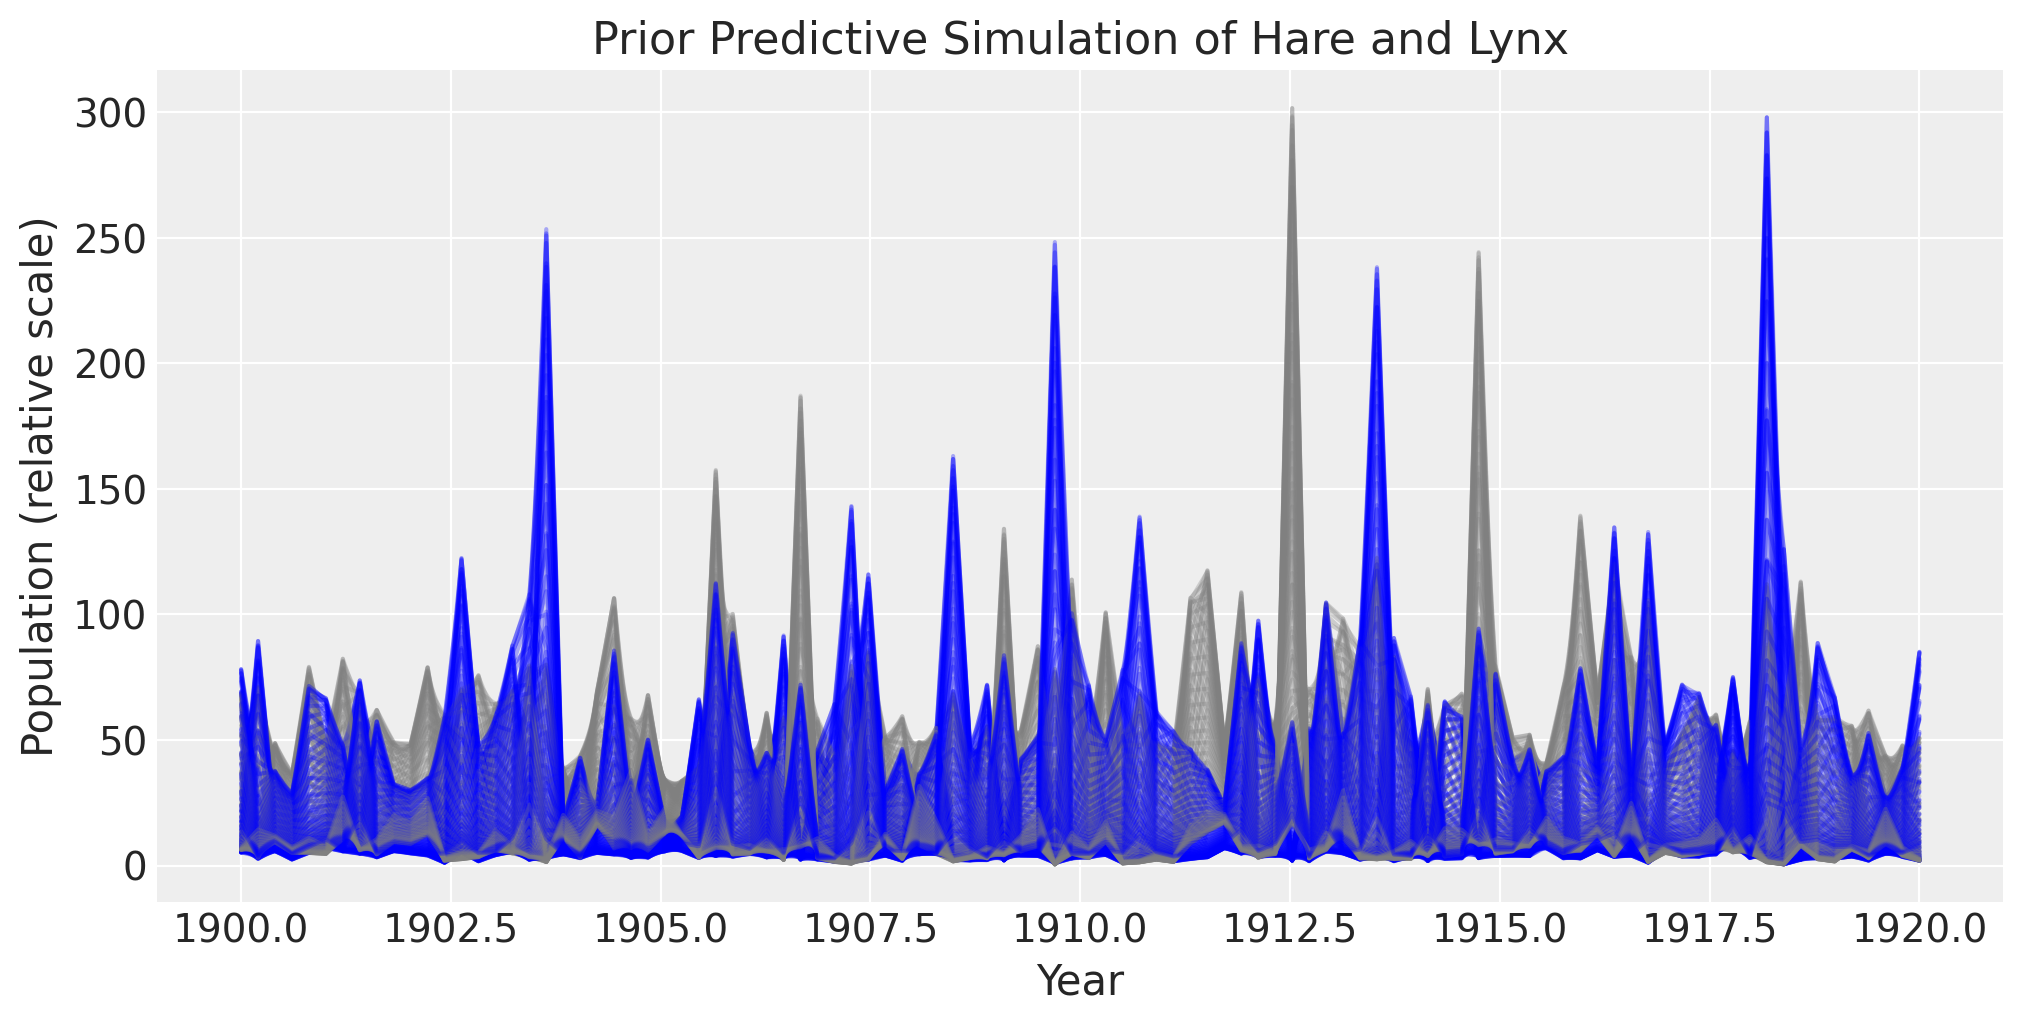

In [71]:
hare = prior_pred.prior["hare"].stack(sample=("chain", "draw")).transpose()
lynx = prior_pred.prior["lynx"].stack(sample=("chain", "draw")).transpose()

_, ax = plt.subplots(figsize=(10, 5))
for i in range(hare.shape[1]):
    ax.plot(TIMES, hare[:, i], color="gray", alpha=0.3)
    ax.plot(TIMES, lynx[:, i], color="blue", alpha=0.3)

ax.set_xlabel("Year")
ax.set_ylabel("Population (relative scale)")
ax.set_title("Prior Predictive Simulation of Hare and Lynx")
plt.show()


that looks more reasonable

16M4.  Modify the cylinder height model to use a sphere instead of a cylinder. What choices do you have to make now? Is this a better model, on a predictive basis? Why or why not?

In [75]:
with pm.Model() as sphere_model:
    sigma = pm.Exponential("sigma", 1)
    k = pm.Exponential("k", 0.5)
    p = pm.Beta("p", 2, 18)

    mu = pm.Deterministic("mu", pm.math.log((4/3) * np.pi * k * p**3 * d.height.values**3))
    w = pm.Lognormal("w", mu=mu, sigma=sigma, observed=d.weight.values)

    trace_sphere = pm.sample(    return_inferencedata=True,
        idata_kwargs={"log_likelihood": True})


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, k, p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [78]:
pm.waic(trace_sphere)

Computed from 4000 posterior samples and 352 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1040.85    15.64
p_waic        2.36        -

In [80]:
pm.waic(trace_16_1_mod)

Computed from 4000 posterior samples and 352 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1012.04    14.21
p_waic        3.00        -

In [83]:
pm.waic(trace_16_1)

Computed from 4000 posterior samples and 352 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1040.76    15.64
p_waic        2.25        -

In [84]:
az.compare({"cylinder": trace_16_1_mod, "sphere": trace_sphere}, method="BB-pseudo-BMA")

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
cylinder,0,-1012.046358,2.999585,0.000000,9.999995e-01,13.856448,0.000000,False,log
sphere,1,-1040.855085,2.360540,28.808727,4.586886e-07,15.340437,7.197427,False,log


16H1.  Modify the Panda nut opening model so that male and female chimpanzees have different maximum adult body mass. The sex variable in data(Panda_nuts) provides the information you need. Be sure to incorporate the fact that you know, prior to seeing the data, that males are on average larger than females at maturity.

In [91]:
data=pd.read_csv('End_of_chapter_problems/data/Panda_nuts.csv', sep=';')
data.head()

,chimpanzee,age,sex,hammer,nuts_opened,seconds,help
0,11,3,m,G,0,61.0,N
1,11,3,m,G,0,37.0,N
2,18,4,f,wood,0,20.0,N
3,18,4,f,G,0,14.0,y
4,18,4,f,L,0,13.0,N


In [93]:
data["sex_code"] = (data["sex"] == "male").astype(int)  # male = 1, female = 0

In [94]:
with pm.Model() as model:
    # Shared female mass prior
    M_f = pm.Normal("M_f", mu=30, sigma=5)

    # Positive offset for males
    delta = pm.HalfNormal("delta", sigma=5)

    # Individual adult mass
    M_individual = pm.Deterministic("M", M_f + delta * data["sex_code"])
    
    # You can now use `M_individual` as a predictor
    # For example, model nuts opened:
    alpha = pm.Normal("alpha", 0, 1)
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.Exponential("sigma", 1)

    mu = alpha + beta * M_individual
    nuts = pm.Normal("nuts", mu=mu, sigma=sigma, observed=data["nuts_opened"])

    trace = pm.sample()


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [M_f, delta, alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [95]:
az.summary(trace)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
M_f,29.282,4.860,22.091,37.855,0.103,0.078,2181.0,1763.0,1.0
alpha,0.027,1.027,-1.590,1.702,0.017,0.016,3833.0,2889.0,1.0
beta,0.421,0.101,0.264,0.576,0.002,0.003,2007.0,1622.0,1.0
delta,3.958,3.073,0.002,7.997,0.053,0.047,2133.0,1557.0,1.0
sigma,14.998,1.004,13.384,16.552,0.016,0.017,3831.0,2775.0,1.0
...,...,...,...,...,...,...,...,...,...
M[79],29.282,4.860,22.091,37.855,0.103,0.078,2181.0,1763.0,1.0
M[80],29.282,4.860,22.091,37.855,0.103,0.078,2181.0,1763.0,1.0
M[81],29.282,4.860,22.091,37.855,0.103,0.078,2181.0,1763.0,1.0
M[82],29.282,4.860,22.091,37.855,0.103,0.078,2181.0,1763.0,1.0


Males are inferred to be heavier than females (delta > 0), in line with prior expectations.
Heavier chimps tend to open more nuts (beta > 0, well supported).
Uncertainty in the male–female mass difference remains large — the data doesn't strongly confirm it beyond the prior.
High variability in the number of nuts opened suggests other important predictors (e.g. tool use, experience, context).

16H2.  Now return to the Panda nut model and try to incorporate individual differences. There are two parameters, ϕ and k, which plausibly vary by individual. Pick one of these, allow it to vary by individual, and use partial pooling to avoid overfitting. The variable chimpanzee in data(Panda_nuts) tells you which observations belong to which individuals.

In [97]:
# Encode chimpanzee as an index
data["chimp_idx"] = pd.Categorical(data["chimpanzee"]).codes
n_chimps = data["chimp_idx"].nunique()

with pm.Model() as nut_model:
    # Hyperpriors for ϕ (maximum skill)
    mu_phi = pm.Normal("mu_phi", mu=1, sigma=1)
    sigma_phi = pm.Exponential("sigma_phi", 1)

    # Individual ϕ per chimp (partial pooling)
    phi = pm.LogNormal("phi", mu=mu_phi, sigma=sigma_phi, shape=n_chimps)

    # Shared learning rate
    k = pm.Exponential("k", 1)

    # Expected number of nuts opened
    mu = phi[data["chimp_idx"]] * (1 - pm.math.exp(-k * data["age"]))  # or trials/experience

    # Observation model (could be Poisson, or Normal if overdispersed)
    nuts = pm.Poisson("nuts", mu=mu, observed=data["nuts_opened"])

    trace = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_phi, sigma_phi, phi, k]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [98]:
az.summary(trace)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_phi,1.946,0.674,0.852,2.930,0.052,0.033,206.0,192.0,1.03
sigma_phi,1.921,0.428,1.276,2.536,0.013,0.010,1181.0,1719.0,1.00
phi[0],2.109,3.660,0.000,4.429,0.175,0.423,646.0,750.0,1.01
phi[1],8.198,9.404,0.404,15.747,0.760,1.485,296.0,226.0,1.03
phi[2],8.034,8.824,0.695,15.750,0.643,1.126,308.0,245.0,1.03
phi[3],2.201,2.691,0.021,4.420,0.166,0.343,368.0,426.0,1.03
phi[4],11.913,11.011,1.805,21.530,0.920,1.593,236.0,184.0,1.03
phi[5],61.575,49.420,20.323,104.563,4.786,8.689,201.0,129.0,1.04
phi[6],7.173,7.764,0.509,13.401,0.647,1.210,259.0,213.0,1.03
phi[7],15.271,16.218,1.662,29.016,1.275,2.403,280.0,195.0,1.03


In [103]:
phi_df

chain  draw       phi
phi_dim_0 chain draw                       
0         0     0         0     0  0.825266
                1         0     1  6.517146
                2         0     2  0.907454
                3         0     3  2.142791
                4         0     4  1.748318
...                     ...   ...       ...
21        3     995       3   995  2.503351
                996       3   996  2.553627
                997       3   997  6.069146
                998       3   998  0.612542
                999       3   999  2.771019

[88000 rows x 3 columns]

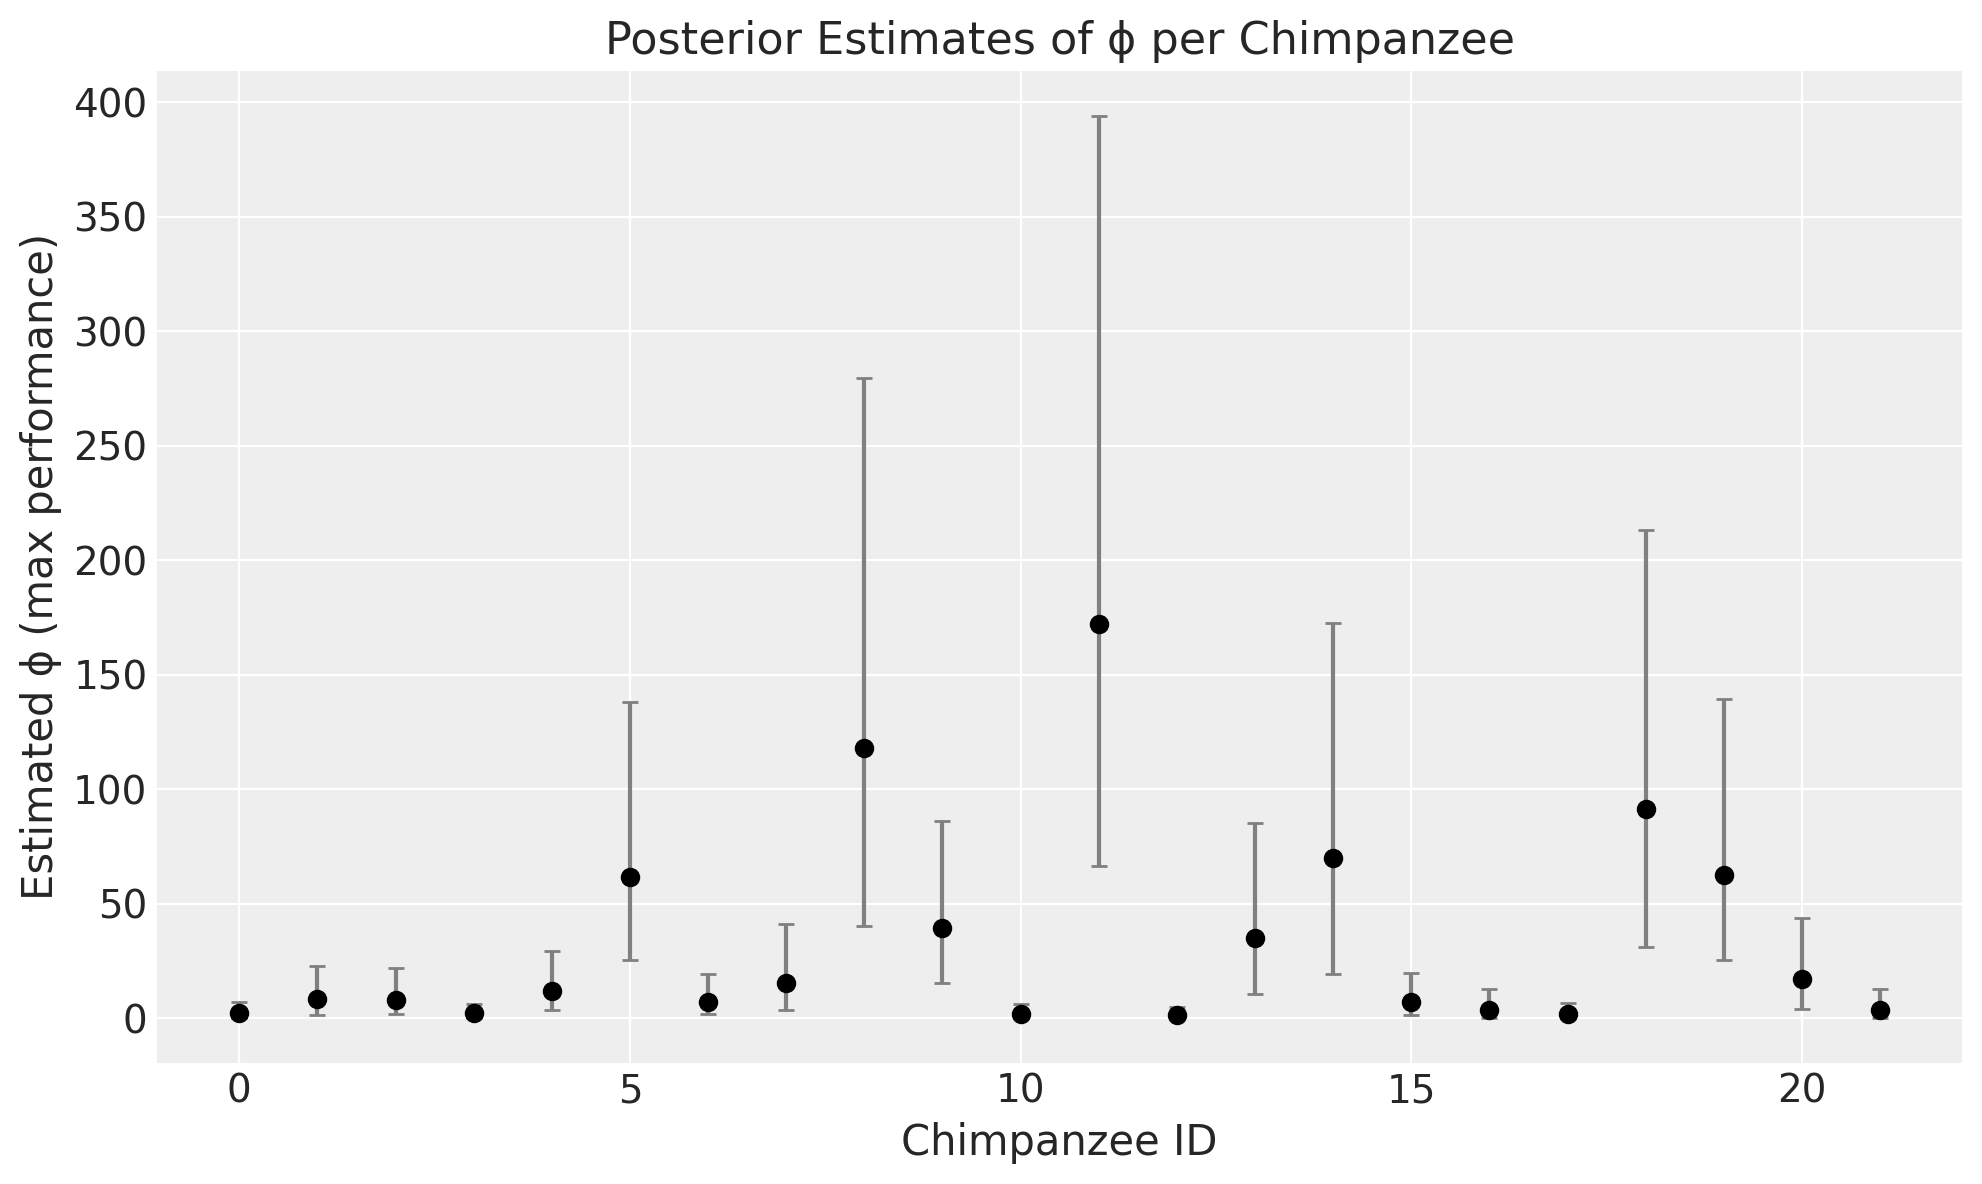

In [104]:
phi_df = az.extract(trace, var_names="phi").to_dataframe()

phi_summary = (
    phi_df.groupby("phi_dim_0")["phi"]
    .agg(["mean", lambda x: np.quantile(x, 0.055), lambda x: np.quantile(x, 0.945)])
    .rename(columns={"<lambda_0>": "hdi_5.5%", "<lambda_1>": "hdi_94.5%"})
)

fig, ax = plt.subplots(figsize=(10, 6))

chimp_ids = range(len(phi_summary))
means = phi_summary["mean"]
lower = phi_summary["hdi_5.5%"]
upper = phi_summary["hdi_94.5%"]

ax.errorbar(
    x=chimp_ids,
    y=means,
    yerr=[means - lower, upper - means],
    fmt="o",
    ecolor="gray",
    capsize=3,
    color="black"
)

ax.set_xlabel("Chimpanzee ID")
ax.set_ylabel("Estimated ϕ (max performance)")
ax.set_title("Posterior Estimates of ϕ per Chimpanzee")
plt.grid(True)
plt.tight_layout()
plt.show()


Modeled individual differences in skill capacity (ϕ) with partial pooling,
Captured substantial between-chimp variation.

16H3.  The chapter asserts that a typical, geocentric time series model might be one that uses lag variables. Here you’ll fit such a model and compare it to the ODE model in the chapter. An autoregressive time series uses earlier values of the state variables to predict new values of the same variables. These earlier values are called lag variables. You can construct the lag variables here with:

R code 16.21

data(Lynx_Hare)

dat_ar1 <- list(

 L = Lynx_Hare$Lynx[2:21],

 L_lag1 = Lynx_Hare$Lynx[1:20],

 H = Lynx_Hare$Hare[2:21],

 H_lag1 = Lynx_Hare$Hare[1:20] )

Now you can use L_lag1 and H_lag1 as predictors of the outcomes L and H. Like this:

$$
\begin{aligned}
L_t &\sim \mathrm{LogNormal}(\log \mu_{L,t},\, \sigma_L) \\
\mu_{L,t} &= \alpha_L + \beta_{LL} L_{t-1} + \beta_{LH} H_{t-1} \\
H_t &\sim \mathrm{LogNormal}(\log \mu_{H,t},\, \sigma_H) \\
\mu_{H,t} &= \alpha_H + \beta_{HH} H_{t-1} + \beta_{HL} L_{t-1}
\end{aligned}
$$


where Lt–1 and Ht–1 are the lag variables. Use ulam() to fit this model. Be careful of the priors of the α and β parameters. Compare the posterior predictions of the autoregressive model to the ODE model in the chapter. How do the predictions differ? Can you explain why, using the structures of the models?

In [105]:
dat_ar1 = {
    "L": POPULATION["Lynx"].values[1:],        # L_t
    "L_lag1": POPULATION["Lynx"].values[:-1],  # L_{t-1}
    "H": POPULATION["Hare"].values[1:],        # H_t
    "H_lag1": POPULATION["Hare"].values[:-1]   # H_{t-1}
}

In [126]:

with pm.Model() as ar_model:
    # Priors for Lynx
    alpha_L = pm.Normal("alpha_L", mu=0, sigma=10)
    beta_LL = pm.Normal("beta_LL", mu=0, sigma=1)
    beta_LH = pm.Normal("beta_LH", mu=0, sigma=1)
    sigma_L = pm.Exponential("sigma_L", 1)

    # Priors for Hare
    alpha_H = pm.Normal("alpha_H", mu=0, sigma=10)
    beta_HH = pm.Normal("beta_HH", mu=0, sigma=1)
    beta_HL = pm.Normal("beta_HL", mu=0, sigma=1)
    sigma_H = pm.Exponential("sigma_H", 1)

    # Linear predictors
    mu_L_raw = alpha_L + beta_LL * dat_ar1["L_lag1"] + beta_LH * dat_ar1["H_lag1"]
    mu_H_raw = alpha_H + beta_HH * dat_ar1["H_lag1"] + beta_HL * dat_ar1["L_lag1"]

    # Ensure positivity
    mu_L = pt.log1p(pt.exp(mu_L_raw))  # log(1 + exp(x))
    mu_H = pt.log1p(pt.exp(mu_H_raw))

    # Likelihood
    L_obs = pm.LogNormal("L", mu=pt.log(mu_L), sigma=sigma_L, observed=dat_ar1["L"])
    H_obs = pm.LogNormal("H", mu=pt.log(mu_H), sigma=sigma_H, observed=dat_ar1["H"])

    trace_ar1 = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True,
                         idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_L, beta_LL, beta_LH, sigma_L, alpha_H, beta_HH, beta_HL, sigma_H]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [113]:
az.summary(trace_ar1, var_names=["alpha_L", "beta_LL", "beta_LH", "sigma_L",
                                 "alpha_H", "beta_HH", "beta_HL", "sigma_H"])


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_L,-3.733,1.965,-6.985,-0.810,0.047,0.051,1848.0,1859.0,1.0
beta_LL,0.626,0.111,0.457,0.798,0.002,0.003,2249.0,2205.0,1.0
beta_LH,0.307,0.057,0.220,0.398,0.001,0.001,2540.0,2069.0,1.0
sigma_L,0.294,0.055,0.204,0.367,0.001,0.001,3367.0,2143.0,1.0
alpha_H,12.582,3.605,6.923,18.306,0.069,0.059,2734.0,2386.0,1.0
beta_HH,0.808,0.135,0.584,1.005,0.003,0.003,2937.0,2413.0,1.0
beta_HL,-0.353,0.084,-0.486,-0.225,0.001,0.002,3428.0,2477.0,1.0
sigma_H,0.332,0.061,0.240,0.421,0.001,0.001,3109.0,2482.0,1.0


Sampling: [H, L]


Output()

array([<Axes: xlabel='L'>, <Axes: xlabel='H'>], dtype=object)

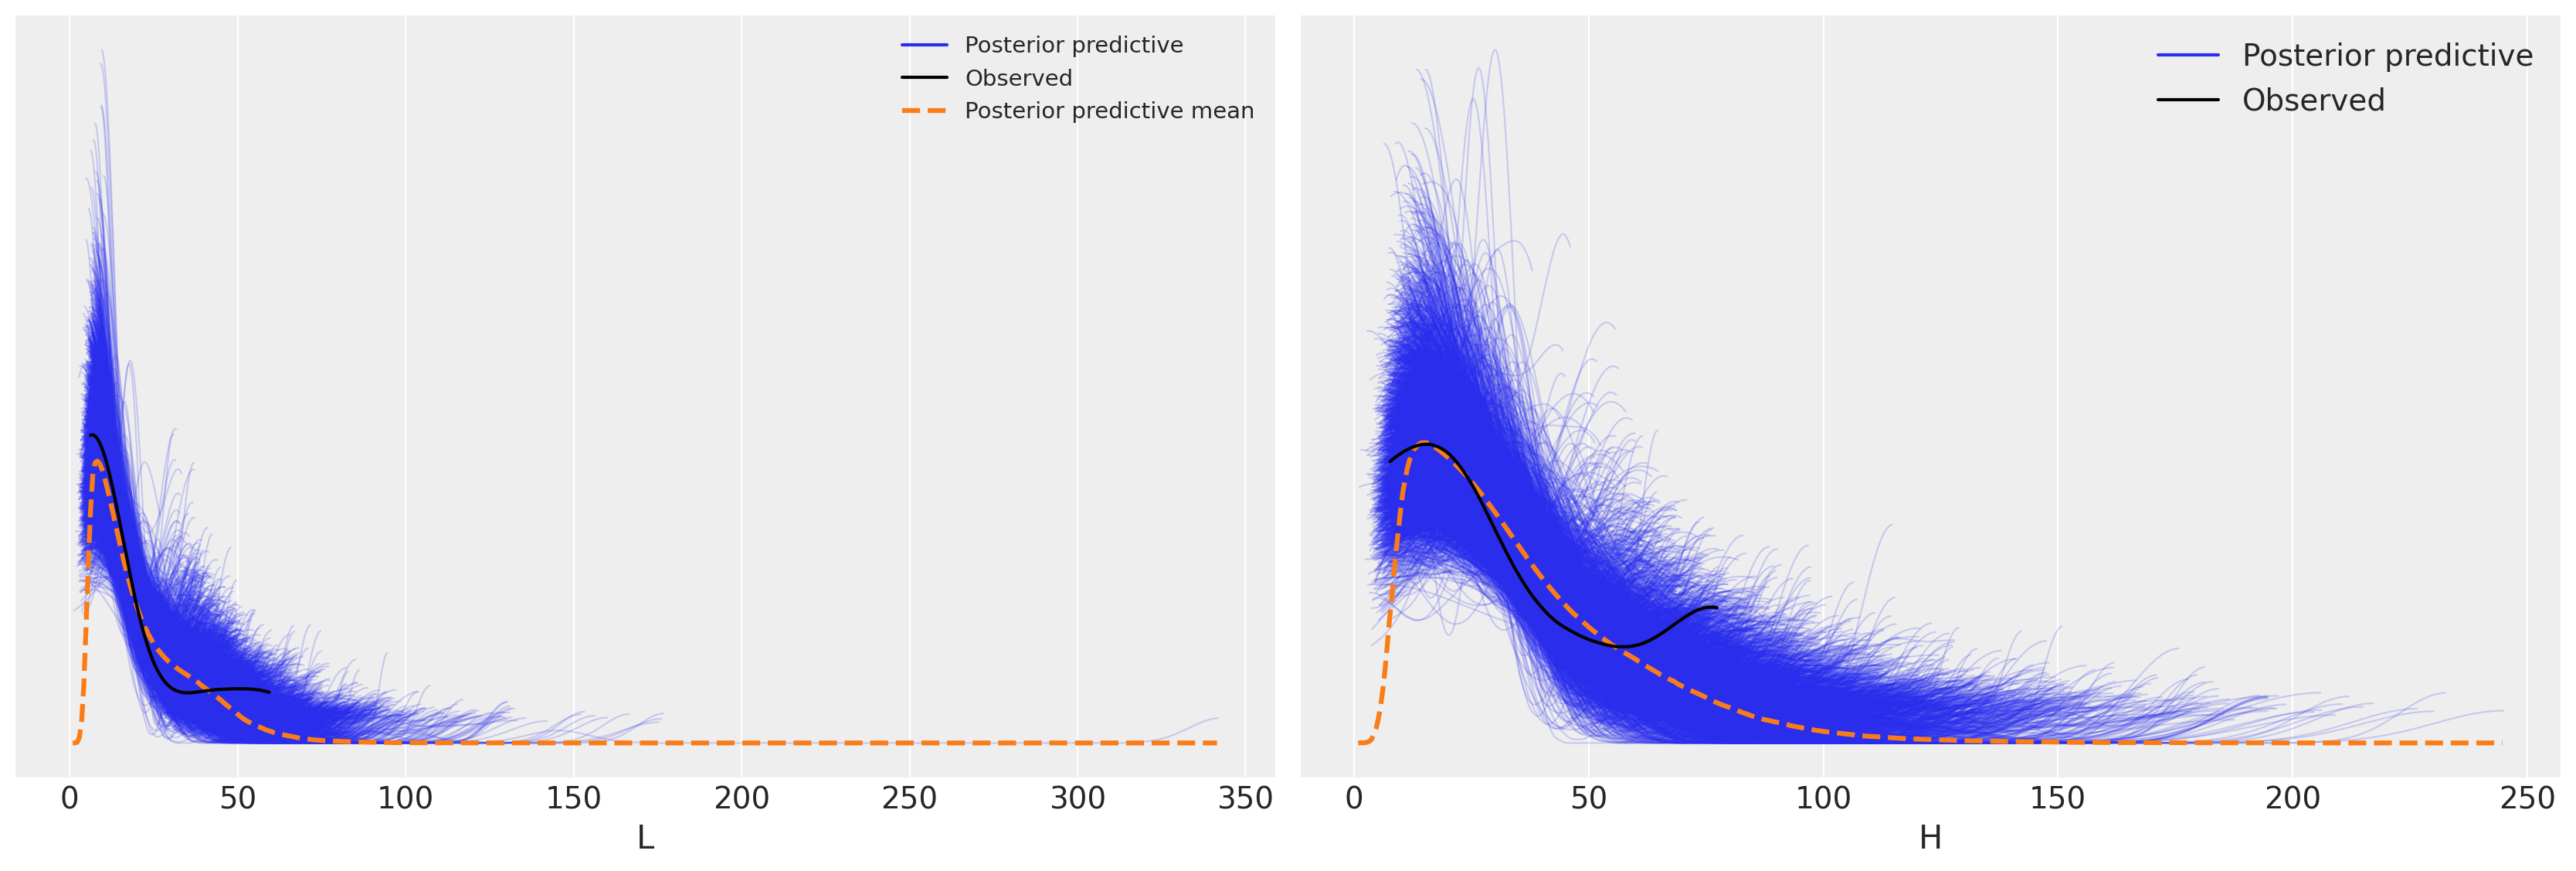

In [114]:
with ar_model:
    ppc_ar1 = pm.sample_posterior_predictive(trace_ar1, var_names=["L", "H"])

az.plot_ppc(ppc_ar1, data_pairs={"L": "L", "H": "H"})


Autorgressive model:
 - Flexible and can fit short-term trends easily.
- Captures empirical correlations but doesn't explain why populations change.
- Lacks biological meaning (e.g., reproduction, predation aren’t modeled).
- Predictions tend to regress to the mean and may miss cyclical behavior.

Lotka-Volterra:
- Encodes ecological theory: predator-prey interactions, feedback loops.

- Naturally produces cyclical dynamics (hare boom → lynx boom → crash → repeat).

- May miss short-term deviations or overfit cycles.

- Less flexible: assumes model structure is approximately correct.

16H4.  Adapt the autoregressive model to use a two-step lag variable. This means that Lt–2 and Ht–2, in addition to Lt–1 and Ht–1, will appear in the equation for μ. This implies that prediction depends upon not only what happened just before now, but also on what happened two time steps ago. How does this model perform, compared to the ODE model?

In [115]:
dat_ar2 = {
    "L": POPULATION["Lynx"].values[2:],
    "L_lag1": POPULATION["Lynx"].values[1:-1],
    "L_lag2": POPULATION["Lynx"].values[:-2],
    "H": POPULATION["Hare"].values[2:],
    "H_lag1": POPULATION["Hare"].values[1:-1],
    "H_lag2": POPULATION["Hare"].values[:-2],
}


In [134]:
with pm.Model() as ar2_model:
    # Priors
    alpha_L = pm.Normal("alpha_L", 0, 10)
    beta_LL1 = pm.Normal("beta_LL1", 0, 1)
    beta_LL2 = pm.Normal("beta_LL2", 0, 1)
    beta_LH1 = pm.Normal("beta_LH1", 0, 1)
    beta_LH2 = pm.Normal("beta_LH2", 0, 1)
    
    alpha_H = pm.Normal("alpha_H", 0, 10)
    beta_HH1 = pm.Normal("beta_HH1", 0, 1)
    beta_HH2 = pm.Normal("beta_HH2", 0, 1)
    beta_HL1 = pm.Normal("beta_HL1", 0, 1)
    beta_HL2 = pm.Normal("beta_HL2", 0, 1)
    
    sigma_L = pm.Exponential("sigma_L", 1)
    sigma_H = pm.Exponential("sigma_H", 1)
    
    # Linear predictors
    mu_L_raw = (
        alpha_L + beta_LL1 * dat_ar2["L_lag1"] + beta_LL2 * dat_ar2["L_lag2"]
        + beta_LH1 * dat_ar2["H_lag1"] + beta_LH2 * dat_ar2["H_lag2"]
    )
    mu_H_raw = (
        alpha_H + beta_HH1 * dat_ar2["H_lag1"] + beta_HH2 * dat_ar2["H_lag2"]
        + beta_HL1 * dat_ar2["L_lag1"] + beta_HL2 * dat_ar2["L_lag2"]
    )

    # Ensure positive means
    mu_L = pt.log1p(pt.exp(mu_L_raw))
    mu_H = pt.log1p(pt.exp(mu_H_raw))

    # Likelihood
    L_obs = pm.LogNormal("L", mu=pt.log(mu_L), sigma=sigma_L, observed=dat_ar2["L"])
    H_obs = pm.LogNormal("H", mu=pt.log(mu_H), sigma=sigma_H, observed=dat_ar2["H"])

    trace_ar2 = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True,
                         idata_kwargs={"log_likelihood": True})
    trace_ar2.extend(pm.sample_posterior_predictive(trace_ar2, extend_inferencedata=True))


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_L, beta_LL1, beta_LL2, beta_LH1, beta_LH2, alpha_H, beta_HH1, beta_HH2, beta_HL1, beta_HL2, sigma_L, sigma_H]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.
There were 11 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [H, L]


Output()

In [136]:
az.summary(trace_ar2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_L,-2.801,2.671,-7.040,1.368,0.053,0.046,2630.0,2312.0,1.0
beta_LL1,0.790,0.276,0.331,1.202,0.006,0.005,1945.0,2095.0,1.0
beta_LL2,-0.085,0.143,-0.314,0.135,0.003,0.003,2293.0,2260.0,1.0
beta_LH1,0.390,0.157,0.152,0.652,0.004,0.003,1778.0,2193.0,1.0
beta_LH2,-0.147,0.218,-0.469,0.222,0.005,0.004,1705.0,1801.0,1.0
alpha_H,11.114,5.025,3.290,19.346,0.108,0.087,2190.0,1999.0,1.0
beta_HH1,0.685,0.305,0.171,1.130,0.007,0.006,1725.0,2089.0,1.0
beta_HH2,0.257,0.458,-0.455,0.976,0.011,0.008,1609.0,2185.0,1.0
beta_HL1,-0.682,0.548,-1.577,0.155,0.014,0.010,1577.0,2042.0,1.0
beta_HL2,0.163,0.232,-0.194,0.534,0.006,0.004,1648.0,2036.0,1.0


In [141]:
az.waic(trace_ar2, var_name="L")

Computed from 4000 posterior samples and 19 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -59.40     3.53
p_waic        3.70        -

There has been a warning during the calculation. Please check the results.

In [ ]:
az.waic(trace_ar2, var_name="H")

Computed from 4000 posterior samples and 19 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -71.46     3.73
p_waic        4.09        -

There has been a warning during the calculation. Please check the results.

In [142]:
az.waic(trace_ar1, var_name="L")

Computed from 4000 posterior samples and 20 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -60.51     4.06
p_waic        3.14        -

There has been a warning during the calculation. Please check the results.

In [143]:
az.waic(trace_ar1, var_name="H")

Computed from 4000 posterior samples and 20 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -74.33     4.00
p_waic        3.17        -

There has been a warning during the calculation. Please check the results.

Sampling: [H, L]


Output()

array([<Axes: xlabel='L'>, <Axes: xlabel='H'>], dtype=object)

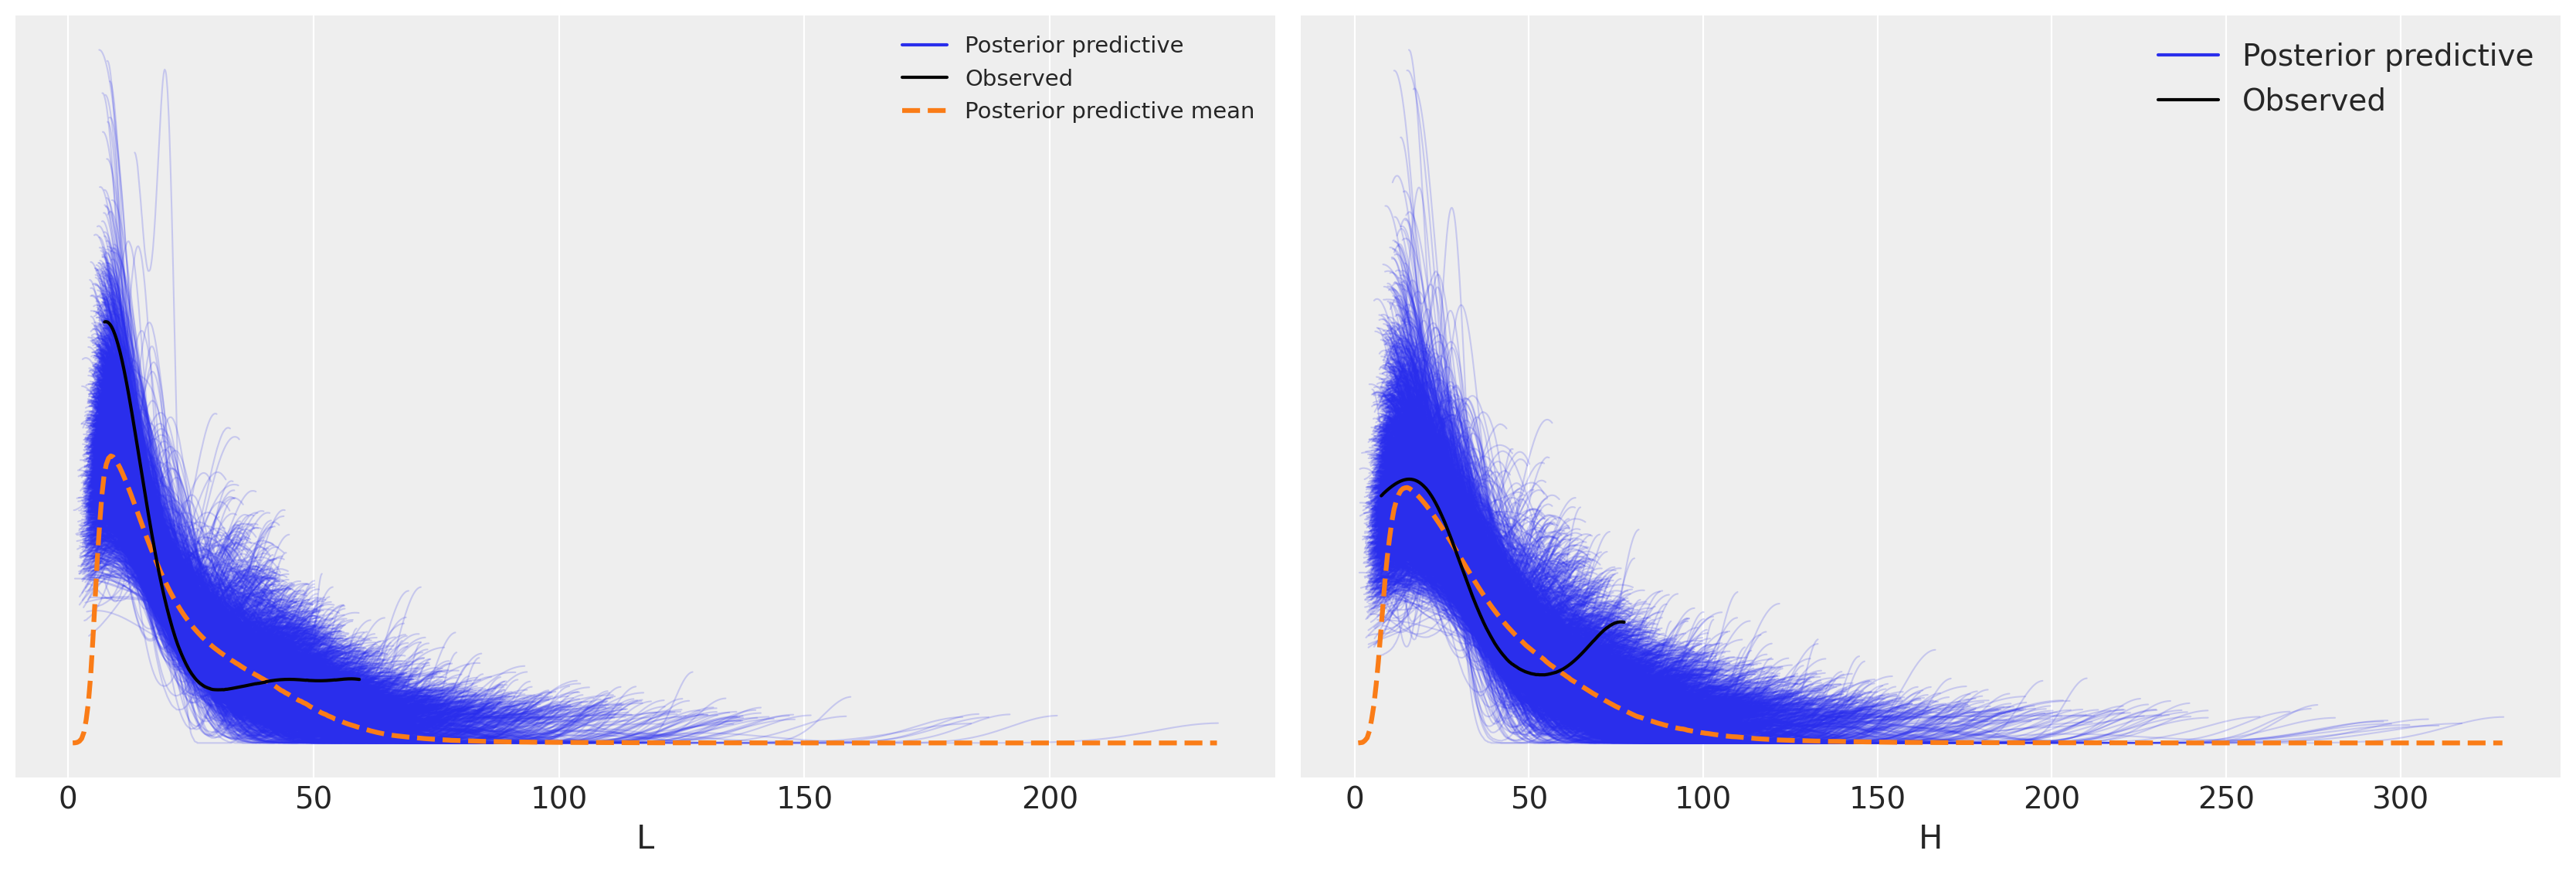

In [119]:
with ar2_model:
    ppc_ar2 = pm.sample_posterior_predictive(trace_ar2, var_names=["L", "H"])

az.plot_ppc(ppc_ar2, data_pairs={"L": "L", "H": "H"})

The AR(2) model acts like a flexible statistical surface: it's good at interpolating within your data but doesn't “know” about biology or constraints. It tells you what happened, not why.

The ODE model is a mechanistic simulation. Even if it fits slightly worse, it provides a causal explanation rooted in theory (birth/mortality dynamics). This is its main strength.

16H5.  Population dynamic models are typically very difficult to fit to empirical data. The lynx-hare example in the chapter was easy, partly because the data are unusually simple and partly because the chapter did the difficult prior selection for you. Here’s another data set that will impress upon you both how hard the task can be and how badly Lotka-Volterra fits empirical data in general. The data in data(Mites) are numbers of predator and prey mites living on fruit.241 Model these data using the same Lotka-Volterra ODE system from the chapter. These data are actual counts of individuals, not just their pelts. You will need to adapt the Stan code in data(Lynx_Hare_model). Note that the priors will need to be rescaled, because the outcome variables are on a different scale. Prior predictive simulation will help. Keep in mind as well that the time variable and the birth and death parameters go together. If you rescale the time dimension, that implies you must also rescale the parameters.

In [144]:
df_mites=pd.read_csv('End_of_chapter_problems/data/Mites.csv', sep=';')
df_mites.shape

(35, 3)

In [146]:
df_mites.head()

,day,prey,predator
0,16,194,75
1,23,896,119
2,29,1443,488
3,36,851,960
4,42,308,458


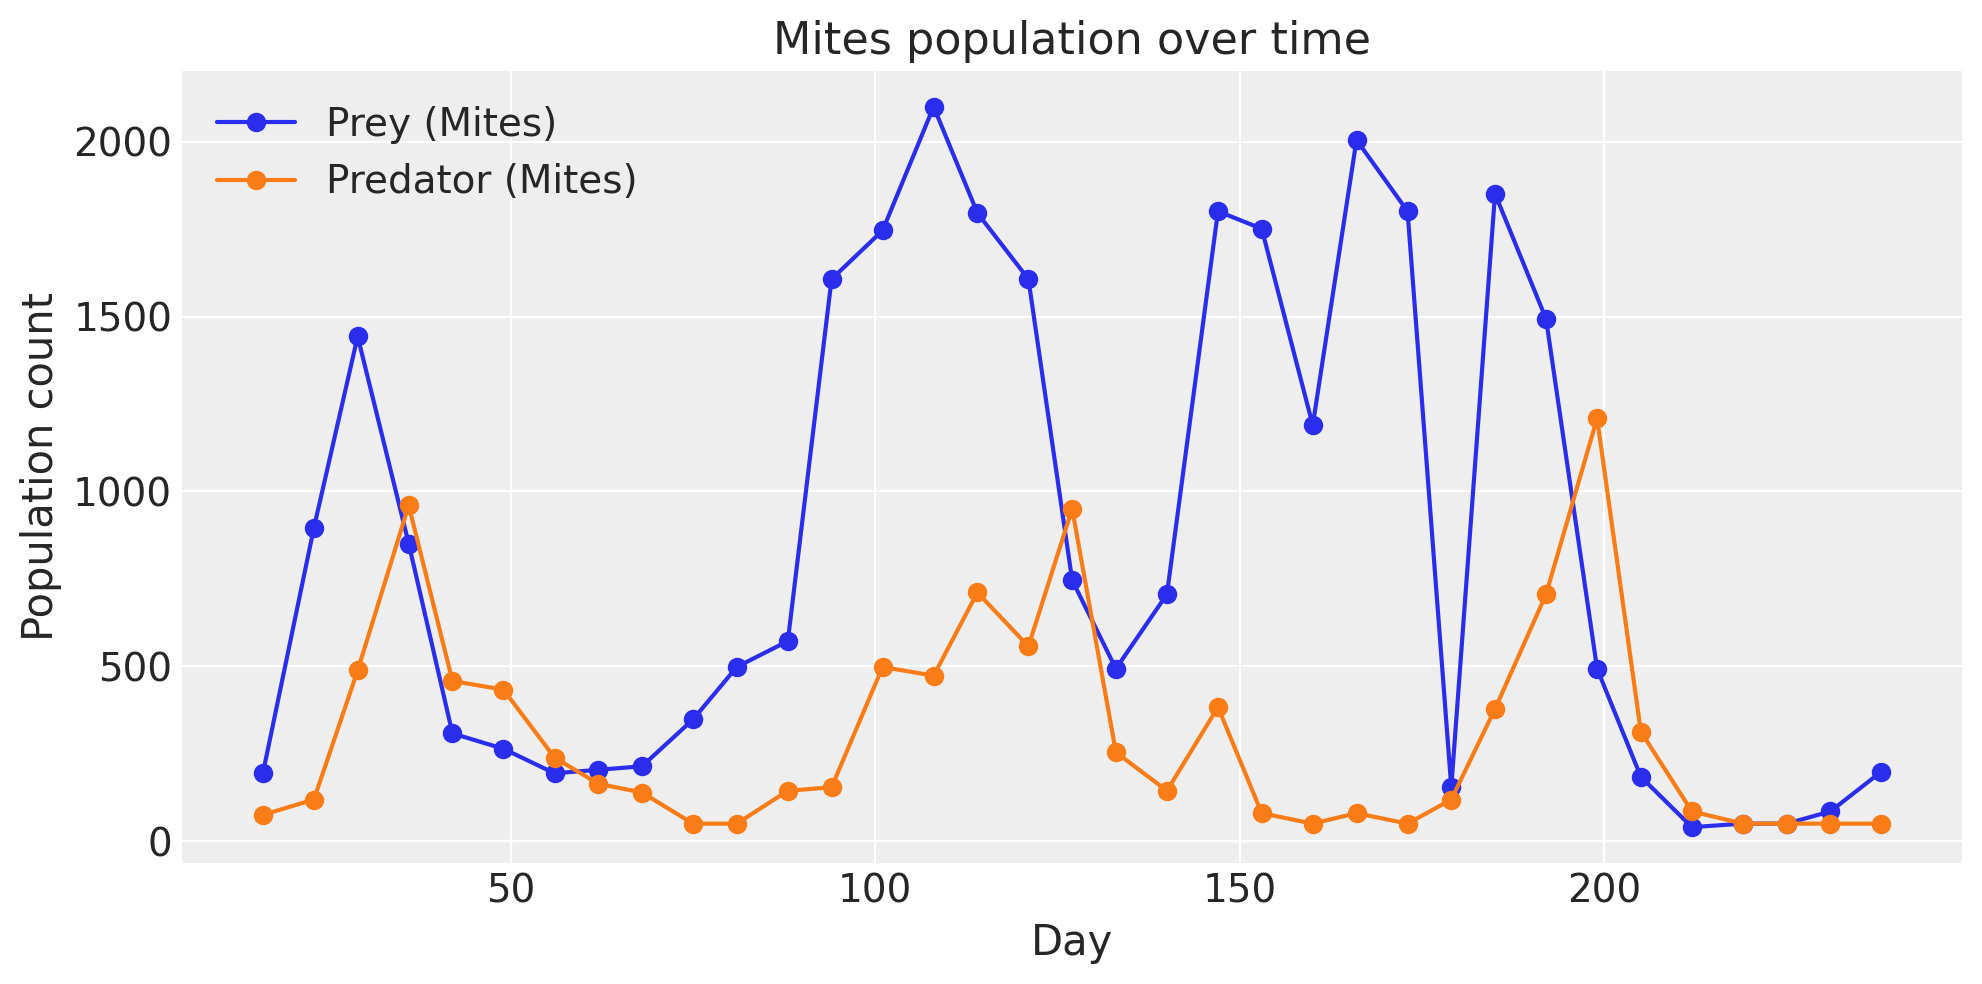

In [147]:
# Plot the raw Mites data
plt.figure(figsize=(10, 5))
plt.plot(df_mites["day"], df_mites["prey"], label="Prey (Mites)", marker="o")
plt.plot(df_mites["day"], df_mites["predator"], label="Predator (Mites)", marker="o")
plt.xlabel("Day")
plt.ylabel("Population count")
plt.title("Mites population over time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [152]:
df_mites["time"] = (df_mites["day"] - df_mites["day"].min()) / 10
times = df_mites["time"].values
prey_obs = df_mites["prey"].values
pred_obs = df_mites["predator"].values

def lv_diffeq(y, t, p):
    prey = y[0]
    pred = y[1]
    bP = p[0]
    mP = p[1]
    bC = p[2]
    mC = p[3]

    dprey = bP * prey - mP * prey * pred
    dpred = -mC * pred + bC * prey * pred

    return [dprey, dpred]


# PyMC ODE wrapper
lv_ode = DifferentialEquation(
    func=lv_diffeq,
    times=times,
    n_states=2,
    n_theta=4,
    t0=times[0]
)

def lv_diffeq(y, t, p):
    prey = pt.clip(y[0], 1e-6, 1e6)
    pred = pt.clip(y[1], 1e-6, 1e6)

    bP = p[0]
    mP = p[1]
    bC = p[2]
    mC = p[3]

    dprey = bP * prey - mP * prey * pred
    dpred = -mC * pred + bC * prey * pred
    return [dprey, dpred]


# --- Step 3: PyMC Model ---
lv_ode = pm.ode.DifferentialEquation(
    func=lv_diffeq,
    times=times,
    n_states=2,
    n_theta=4,
    t0=0.0
)

with pm.Model() as lv_mites_model:
    # Priors for initial conditions
    initial_prey = pm.LogNormal("initial_prey", mu=np.log(100), sigma=0.5)
    initial_pred = pm.LogNormal("initial_pred", mu=np.log(50), sigma=0.5)

    # Safer priors for birth/death rates
    bP = pm.LogNormal("bP", mu=np.log(1.0), sigma=0.5)
    mP = pm.LogNormal("mP", mu=np.log(0.01), sigma=0.5)
    bC = pm.LogNormal("bC", mu=np.log(0.01), sigma=0.5)
    mC = pm.LogNormal("mC", mu=np.log(1.0), sigma=0.5)

    # ODE system solution
    y_hat = lv_ode(y0=[initial_prey, initial_pred], theta=[bP, mP, bC, mC])

    # Observation noise
    sigma_prey = pm.Exponential("sigma_prey", 1)
    sigma_pred = pm.Exponential("sigma_pred", 1)

    # Likelihoods
    pm.Normal("prey_obs", mu=y_hat[:, 0], sigma=sigma_prey, observed=prey_obs)
    pm.Normal("pred_obs", mu=y_hat[:, 1], sigma=sigma_pred, observed=pred_obs)

    # Sample
    trace_mites = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [initial_prey, initial_pred, bP, mP, bC, mC, sigma_prey, sigma_pred]


Output()

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/ode/ode.py:133: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  sol = scipy.integrate.odeint(
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/ode/ode.py:133: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  sol = scipy.integrate.odeint(
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/ode/ode.py:133: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  sol = scipy.integrate.odeint(


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.7000000000000D+00   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.7000000000000D+00   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.7000000000000D+00   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.7000000000000D+00   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.7000000000000D+00   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2) 

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/ode/ode.py:133: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = scipy.integrate.odeint(


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.7000000000000D+00   r2 =                  NaN
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5355822031697D+01   r2 =  0.2067018646374D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5355822031697D+01   r2 =  0.4134037292748D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5355822031697D+01   r2 =  0.4134037292748D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t o

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/ode/ode.py:133: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = scipy.integrate.odeint(


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28478 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [154]:
az.summary(trace_mites)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
initial_prey,1104.681,247.911,648.670,1332.923,120.193,67.639,7.0,30.0,1.53
initial_pred,118.096,63.632,58.203,232.807,30.310,18.124,7.0,31.0,1.53
bP,0.678,0.457,0.309,1.429,0.213,0.137,7.0,34.0,1.53
mP,0.002,0.002,0.001,0.005,0.001,0.000,7.0,33.0,1.53
bC,0.003,0.001,0.002,0.004,0.000,0.000,8.0,32.0,1.47
mC,2.075,0.629,1.360,3.040,0.254,0.177,8.0,34.0,1.46
sigma_prey,226.057,14.526,205.429,250.330,6.021,2.846,8.0,30.0,1.49
sigma_pred,98.546,20.906,78.420,135.767,10.091,5.721,7.0,31.0,1.53
